In [32]:
# --- Setup: all imports in one place ---
import glob
import json
import importlib.util
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

# Figure resolution. "retina" doubles the pixel density of every inline figure
# without changing its on-screen size or layout; savefig.dpi only affects files
# written with fig.savefig(...), which stay at print resolution.
%config InlineBackend.figure_format = "retina"
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

In [33]:
from pathlib import Path
RECORDINGS_DIR = Path("recordings-download/*/")
RECORDINGS_BASE = Path("recordings-download/")

score_r1 = "oth_score_poc20260727.json"
score_r3 = "oth_score_pbg20260726.json"
score_r2 = "oth_score_pb220260706.json"
conversations = "conversation_poc20260727.jsonl"
post_survey_1 = "post_survey_poc20260727.json"
post_survey_2 = "post_survey_pbg20260726.json"

In [34]:
# Participants who had both r1 and r2
all_r1 = glob.glob(str(RECORDINGS_DIR / score_r1))
all_r1 = [x.split("/")[-2] for x in all_r1]
all_r2 = glob.glob(str(RECORDINGS_DIR / score_r2))
all_r2 = [x.split("/")[-2] for x in all_r2]

all_candidates = set(all_r1).intersection(set(all_r2))
all_candidates

{'p786',
 'p226',
 'p277',
 'p780',
 'p158',
 'p62',
 'p405',
 'p602',
 'p752',
 'p777',
 'p131',
 'p805',
 'p591',
 'p621',
 'p705',
 'p593',
 'p150',
 'p642',
 'p717',
 'p635',
 'p528',
 'p632',
 'p99',
 'p688',
 'p813',
 'p268',
 'p477',
 'p258',
 'p791',
 'p357',
 'p404',
 'p92',
 'p262',
 'p706',
 'p314',
 'p157',
 'p838',
 'p266',
 'p545',
 'p573',
 'p334',
 'p798',
 'p611',
 'p454',
 'p383',
 'p17',
 'p669',
 'p76',
 'p812',
 'p286',
 'p722',
 'p155',
 'p127',
 'p86',
 'p233',
 'p749',
 'p723',
 'p322',
 'p534',
 'p735',
 'p329',
 'p824',
 'p530',
 'p783',
 'p578',
 'p807',
 'p123',
 'p797',
 'p380',
 'p707',
 'p241',
 'p636',
 'p199',
 'p616',
 'p33',
 'p392',
 'p137',
 'p523',
 'p426',
 'p346',
 'p535',
 'p736',
 'p785',
 'p576',
 'p484',
 'p726',
 'p745',
 'p222',
 'p30',
 'p212',
 'p658',
 'p460',
 'p729',
 'p708',
 'p815',
 'p795',
 'p629',
 'p843',
 'p679',
 'p61',
 'p608',
 'p55',
 'p368',
 'p393',
 'p284',
 'p628',
 'p72',
 'p395',
 'p161',
 'p240',
 'p823',
 'ovieCommem

In [35]:
len(all_candidates)

112

# Score Differences

In [36]:
# Mean / median / std for a field, across a set of participants.
# nasa_tlx=True reads post_survey["nasa_tlx"][field] instead of a top-level field.
import os
def report_avg(fn, kn, cands=all_candidates, nasa_tlx=False):
    vals = []
    for pid in cands:
        d = json.load(open(RECORDINGS_BASE / pid / fn))
        if not os.path.exists(RECORDINGS_BASE / pid / "conversation_poc20260727.jsonl"):
            continue
        try:
            vals.append(d["nasa_tlx"][kn] if nasa_tlx else int(d[kn]))
        except ValueError:
            vals.append(0)
    return np.mean(vals), np.median(vals), np.std(vals)

# Round-level score summary across all completers
print(f"{'round':>10} {'metric':>14} {'mean':>6} {'median':>7} {'std':>6}")
for rlabel, fn, kn in [("R1 (AI)", score_r1, "final_margin"), ("R2 (no AI)", score_r2, "final_margin"), ("R3 (no AI)", score_r3, "final_margin")]:
    m, md, sd = report_avg(fn, kn)
    print(f"{rlabel:>10} SCORE {m:>6.2f} {md:>7.1f} {sd:>6.2f}")

     round         metric   mean  median    std
   R1 (AI) SCORE  -8.75   -18.0  15.85
R2 (no AI) SCORE  -3.76    -2.0   7.78
R3 (no AI) SCORE -10.38   -10.0   8.33


# Separate Solvers vs. Strugglers

In [37]:
# Merged 2-group split: won = score >= 2 (former win + won), lost = the rest.
good_pid, bad_pid = [], []
win_pid = []   # merged into won; kept empty so any legacy references still work
for pid in all_candidates:
    curr_f_r2 = json.load(open(RECORDINGS_BASE / pid / score_r2))
    curr_f_r3 = json.load(open(RECORDINGS_BASE / pid / score_r3))
    if not os.path.exists(RECORDINGS_BASE / pid / "conversation_poc20260727.jsonl"):
        continue
    dem_file = json.load(open(RECORDINGS_BASE / pid / "demographics.json"))
    # if dem_file["skill_rating"] == "dont_know":
    #     continue
    if curr_f_r2["score"] + curr_f_r3["score"] > 0.5 * (curr_f_r2["decisions"] + curr_f_r3["decisions"]):
    # if curr_f_r2["solved"] or curr_f_r3["solved"]:
        good_pid.append(pid)
    else:
        bad_pid.append(pid)

In [38]:
len(good_pid), len(bad_pid)

(45, 67)

# Demographic Differences

In [39]:
report_avg("demographics.json", "skill_rating", cands=good_pid + win_pid + bad_pid)

(np.float64(1.0178571428571428),
 np.float64(1.0),
 np.float64(0.9256478701924596))

In [40]:
report_avg("demographics.json", "skill_rating", cands=bad_pid)

(np.float64(1.0), np.float64(1.0), np.float64(0.9304147686870865))

In [41]:
report_avg("demographics.json", "age", cands=good_pid + win_pid)

(np.float64(42.91111111111111),
 np.float64(41.0),
 np.float64(10.280125857902762))

In [42]:
report_avg("demographics.json", "age", cands=bad_pid)

(np.float64(42.701492537313435),
 np.float64(40.0),
 np.float64(13.072718459508954))

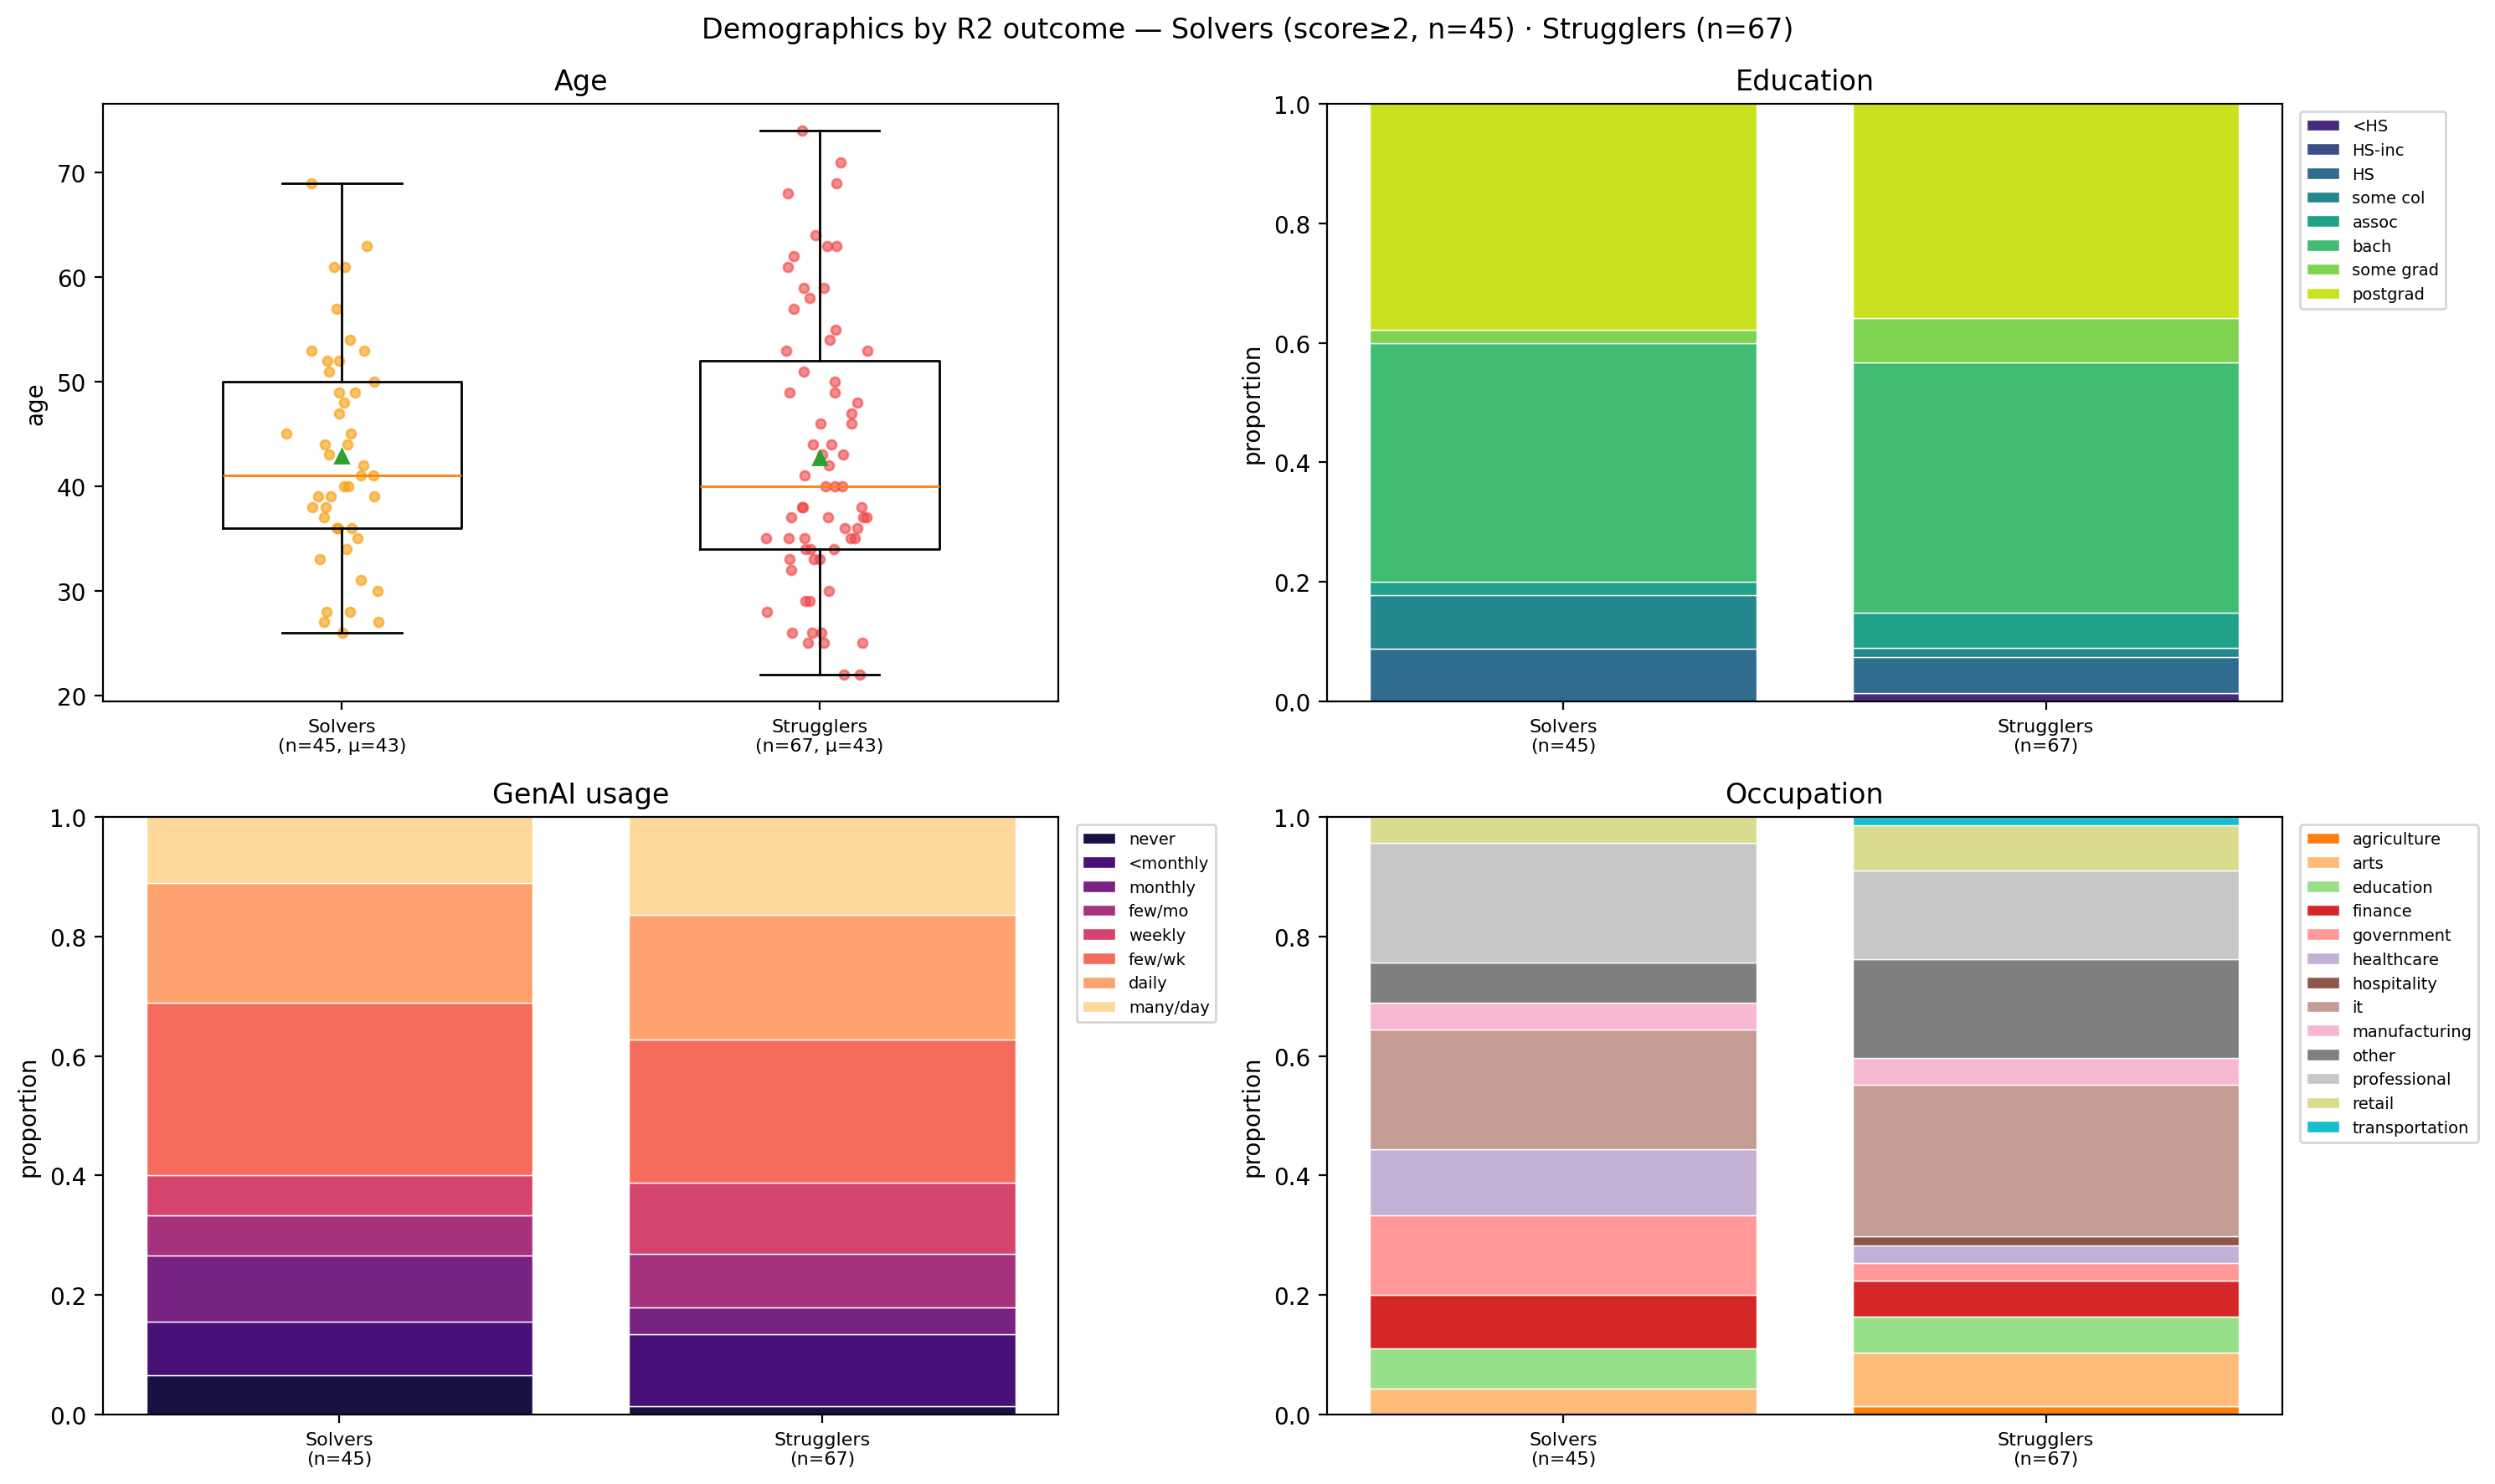

In [43]:
# --- Demographics: good_pid vs win_pid vs bad_pid ---
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def load_demo(cands):
    return [json.load(open(RECORDINGS_BASE / pid / "demographics.json"))
            for pid in cands if (RECORDINGS_BASE / pid / "demographics.json").exists()]

dg, dw, db = load_demo(good_pid), load_demo(win_pid), load_demo(bad_pid)
GROUPS = [("Solvers", dg, "#f59e0b"), ("Strugglers", db, "#ef4444")]

# Ordered categories (app option order) + short labels
EDU = (["less_than_hs","hs_incomplete","hs_graduate","some_college","associate","bachelors","some_postgrad","postgrad"],
       ["<HS","HS-inc","HS","some col","assoc","bach","some grad","postgrad"])
GEN = (["never","less_than_monthly","about_monthly","few_times_month","weekly","few_times_week","daily","several_times_day"],
       ["never","<monthly","monthly","few/mo","weekly","few/wk","daily","many/day"])

def props(demos, key, order):
    n = sum(1 for d in demos if d.get(key) in order) or 1
    c = Counter(d.get(key) for d in demos)
    return np.array([c.get(o, 0) / n for o in order])

def stacked(a, key, order, short, title, cmap="viridis"):
    x = np.arange(len(GROUPS))
    P = np.array([props(d, key, order) for _, d, _ in GROUPS])   # (3 groups, n_cats)
    colors = plt.get_cmap(cmap)(np.linspace(0.12, 0.92, len(order)))
    bottoms = np.zeros(len(GROUPS))
    for ci, lab in enumerate(short):
        a.bar(x, P[:, ci], bottom=bottoms, color=colors[ci], label=lab, edgecolor="white", lw=0.5)
        bottoms += P[:, ci]
    a.set_xticks(x); a.set_xticklabels([f"{nm}\n(n={len(d)})" for nm, d, _ in GROUPS], fontsize=8)
    a.set_ylim(0, 1); a.set_ylabel("proportion"); a.set_title(title)
    a.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)

fig, ax = plt.subplots(2, 2, figsize=(15, 9))

# Age — box + jittered points per group
ages = [[d["age"] for d in demos if d.get("age")] for _, demos, _ in GROUPS]
ax[0,0].boxplot(ages, positions=range(len(GROUPS)), widths=0.5, showmeans=True)
rng = np.random.default_rng(0)
for i, ((nm, _, col), v) in enumerate(zip(GROUPS, ages)):
    ax[0,0].scatter(rng.normal(i, 0.05, len(v)), v, s=16, alpha=0.6, color=col)
ax[0,0].set_xticks(range(len(GROUPS)))
ax[0,0].set_xticklabels([f"{nm}\n(n={len(v)}, μ={np.mean(v):.0f})" for (nm,_,_), v in zip(GROUPS, ages)], fontsize=8)
ax[0,0].set_ylabel("age"); ax[0,0].set_title("Age")

stacked(ax[0,1], "education", *EDU, "Education", cmap="viridis")
stacked(ax[1,0], "genai_usage", *GEN, "GenAI usage", cmap="magma")
occ = sorted({d.get("occupation") for _, dm, _ in GROUPS for d in dm if d.get("occupation")})
stacked(ax[1,1], "occupation", occ, occ, "Occupation", cmap="tab20")

fig.suptitle("Demographics by R2 outcome — Solvers (score≥2, n=%d) · Strugglers (n=%d)"
             % (len(dg), len(db)), fontsize=12)
plt.tight_layout(); plt.show()

# NASA-TLX Differences

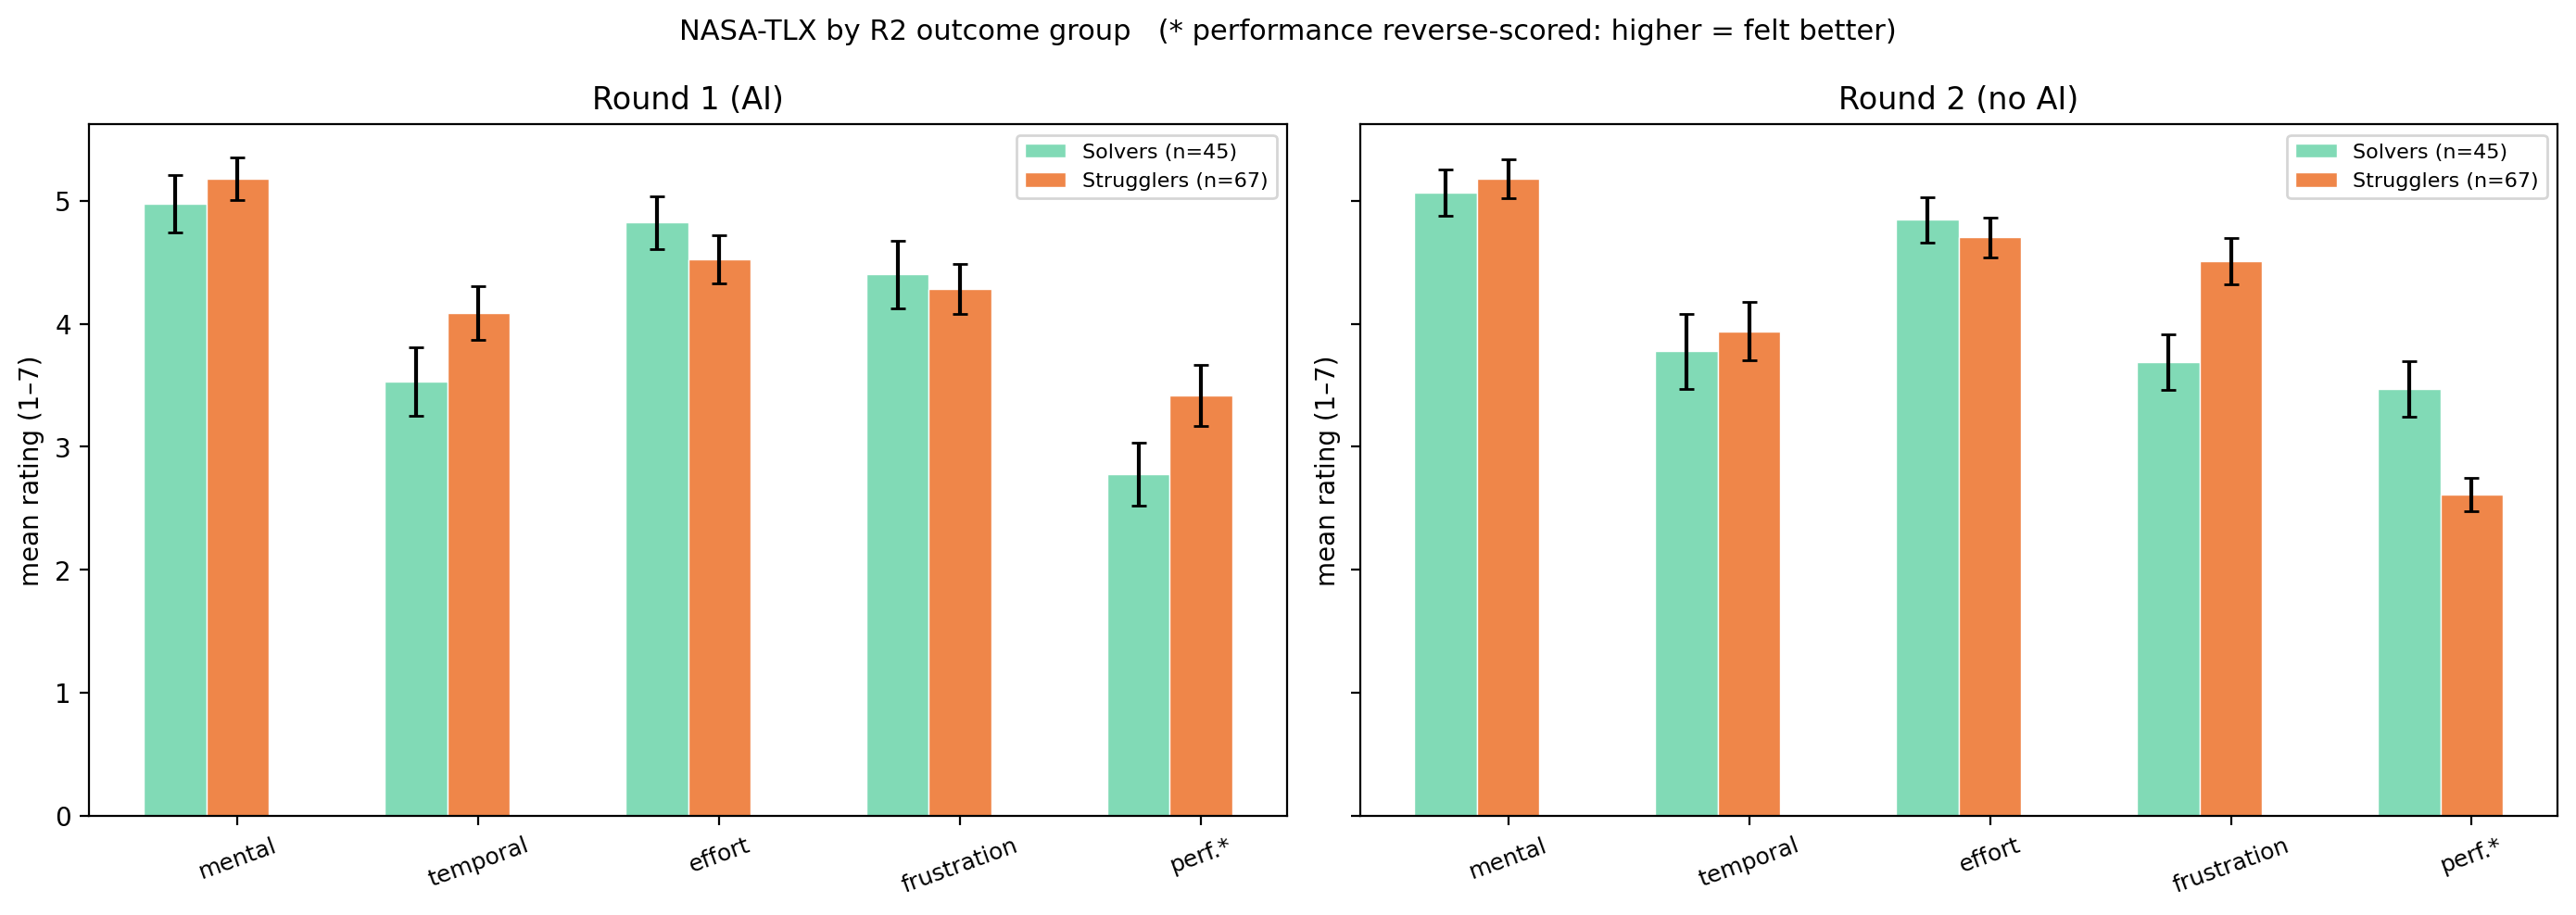

In [44]:
# --- NASA-TLX by R2 outcome group (Solvers / Strugglers), per round ---
# physical_demand was dropped from the instrument (present in only some batch-1
# files), so we compare the 5 current items. performance is reverse-scored:
# a HIGHER rating means the participant felt they did BETTER (lower workload).
TLX_ITEMS = ["mental_demand", "temporal_demand", "effort", "frustration", "performance"]
TLX_SHORT = ["mental", "temporal", "effort", "frustration", "perf.*"]
GROUPST = [("Solvers", good_pid, "#81dab6"), ("Strugglers", bad_pid, "#ef8649")]
ROUNDS = [("Round 1 (AI)", post_survey_1), ("Round 2 (no AI)", post_survey_2)]

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(len(TLX_ITEMS)); w = 0.26
for a, (rlabel, sfile) in zip(ax, ROUNDS):
    for gi, (nm, pids_, col) in enumerate(GROUPST):
        s = [report_avg(sfile, it, cands=pids_, nasa_tlx=True) for it in TLX_ITEMS]
        means = [v[0] for v in s]
        sems = [v[2] / np.sqrt(len(pids_)) for v in s]      # std error of the mean
        a.bar(x + (gi - 1) * w, means, w, yerr=sems, capsize=3, color=col,
              label=f"{nm} (n={len(pids_)})", edgecolor="white", lw=0.5)
    a.set_xticks(x); a.set_xticklabels(TLX_SHORT, rotation=20, fontsize=9)
    a.set_title(rlabel); a.set_ylabel("mean rating (1–7)"); a.legend(fontsize=8)
fig.suptitle("NASA-TLX by R2 outcome group   (* performance reverse-scored: higher = felt better)",
             fontsize=11)
plt.tight_layout(); plt.show()

# Conversation Differences

### Number of Turns

In [45]:
import os
def count_convo_turns(pids):
    turns = []
    for pid in pids:
        convo_f = RECORDINGS_BASE / pid / "conversation_poc20260727.jsonl"
        if os.path.exists(convo_f):
            turns.append(len(open(convo_f).readlines()))
        else:
            turns.append(0)
    return np.mean(turns), np.median(turns), np.std(turns)

print("GOOD (score>=4):", count_convo_turns(good_pid))
print("BAD:", count_convo_turns(bad_pid))

GOOD (score>=4): (np.float64(5.555555555555555), np.float64(5.0), np.float64(1.0446808243149472))
BAD: (np.float64(5.537313432835821), np.float64(5.0), np.float64(1.3964598973989333))


group         n    turns    types   tokens  types/turn    TTR  up P->AI  up AI->P
Solvers      45      5.6     40.7     55.8         7.4   0.76      0.20      0.05
Strugglers   67      5.5     38.3     53.8         6.9   0.74      0.23      0.05
  Mann-Whitney turns          p=0.490
  Mann-Whitney unique words   p=0.186
  Mann-Whitney types/turn     p=0.129
  Mann-Whitney TTR            p=0.495
  Mann-Whitney uptake P->AI   p=0.455
  Mann-Whitney uptake AI->P   p=0.749


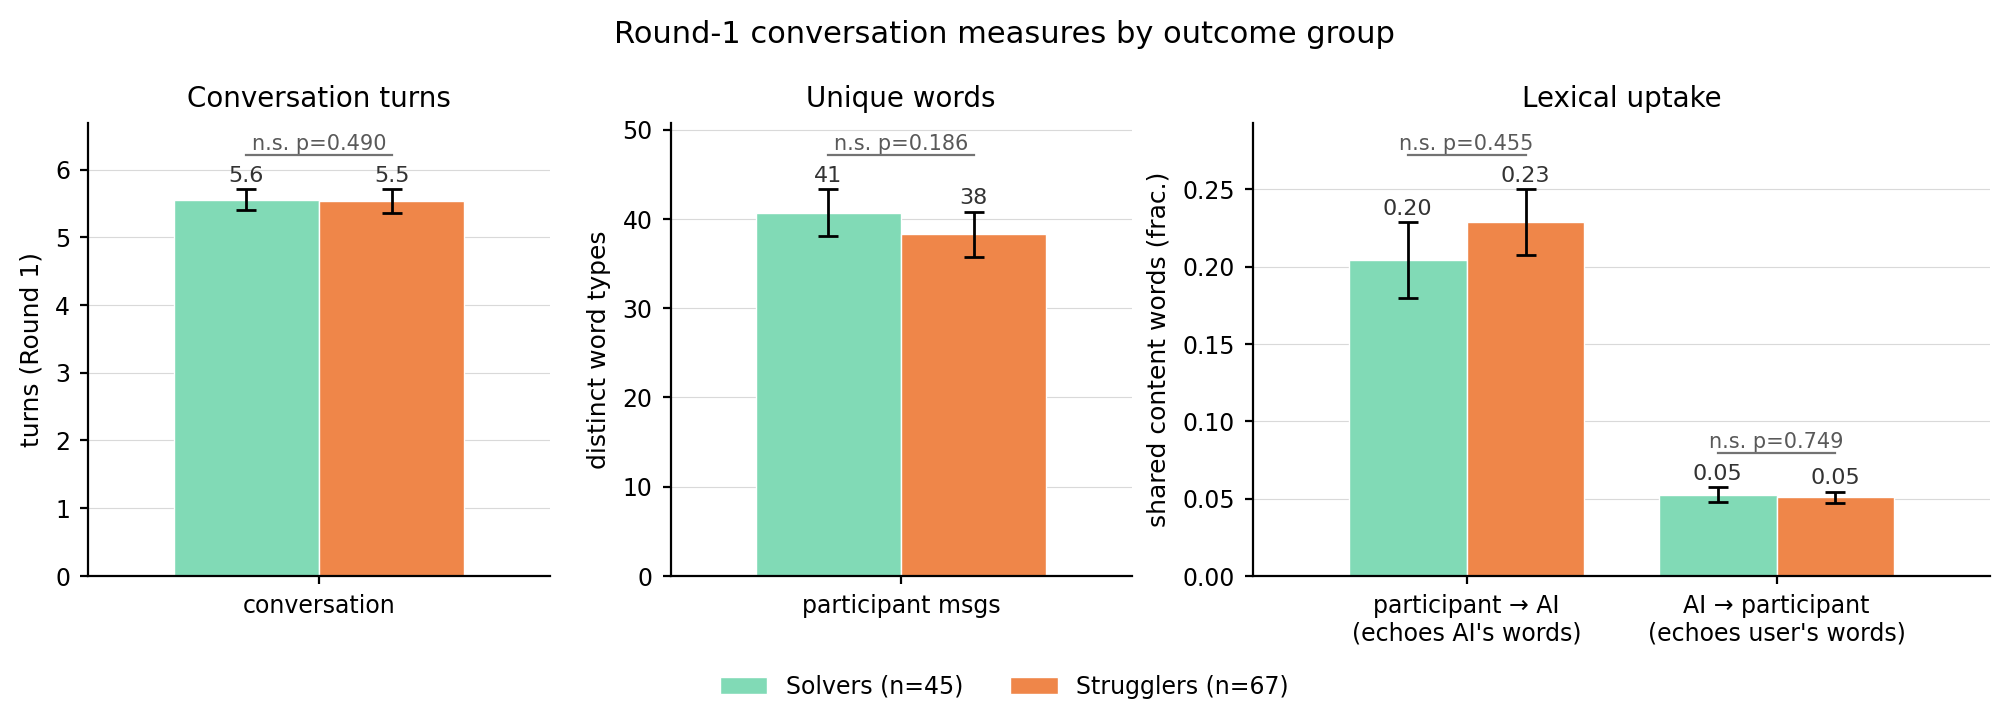

In [46]:
# --- R1 conversation measures: turns, unique words, lexical uptake (Solvers vs Strugglers) ---
# Three panels on the same population as the turns bar chart above.
#  * turns        -- exchanges in conversation_p15.jsonl (one line = one user+assistant pair)
#  * unique words -- distinct word TYPES across a participant's own R1 messages. Grows with
#                    turn count by construction, so the printed table also carries
#                    types-per-turn and TTR (types/tokens) as length-controlled companions.
#  * uptake       -- share of a speaker's CONTENT words that already appeared in the partner's
#                    immediately preceding message (Jaccard-style directional overlap):
#                      participant -> AI : user msg i vs assistant reply i-1  (needs >= 2 turns)
#                      AI -> participant : assistant reply i vs user msg i
#                    This is lexical uptake only -- it measures word reuse, not whether the
#                    idea was actually taken up. Domain vocabulary ("column", "diagonal") is
#                    unavoidable and inflates both directions; flip EXCLUDE_GAME_WORDS to see
#                    uptake with the Connect-Four vocabulary held out.
import re
from scipy.stats import mannwhitneyu

EXCLUDE_GAME_WORDS = False

STOP = set("""a an the and or but if then than so because as of at by for with about into
onto from to in on out up down over under again is are was were be been being am do does did
doing have has had having i you he she it we they me my your his her its our their this that
these those there here what which who whom when where why how all any both each few more most
other some such no nor not only own same too very can will just should now would could may
might must shall im ive youre dont doesnt didnt cant wont thats theres ill id well ok okay yes
yeah no oh hmm think thanks thank please sure lets let get got""".split())

GAME_WORDS = set("""column columns col cols row rows red reds yellow yellows move moves moving
play plays played playing win wins winning won lose loses lost board piece pieces game games
four three two connect diagonal diagonally vertical vertically horizontal horizontally block
blocks blocking opponent turn drop drops threat threats c1 c2 c3 c4 c5 c6 c7 r1 r2 r3 r4 r5
r6""".split())

TOKEN = re.compile(r"[a-z][a-z']*|\d+")

def _toks(s):
    return TOKEN.findall((s or "").lower())

def _content(s):
    """Content-word SET for uptake: stopwords out, 1-2 char tokens out."""
    drop = STOP | (GAME_WORDS if EXCLUDE_GAME_WORDS else set())
    return {w for w in _toks(s) if len(w) > 2 and w not in drop}

def _uptake(cur, prev):
    """Share of the current message's content words seen in the partner's previous one."""
    return len(cur & prev) / len(cur) if cur else np.nan

def convo_measures(pid):
    """Per-participant R1 conversation measures (nan where a measure is undefined)."""
    f = RECORDINGS_BASE / pid / "conversation_poc20260727.jsonl"
    ex = [json.loads(l) for l in open(f) if l.strip()] if f.exists() else []
    if not ex:
        return dict(turns=0, types=0, tokens=0, ttr=np.nan,
                    types_per_turn=np.nan, up_user=np.nan, up_ai=np.nan)
    utoks = [t for e in ex for t in _toks(e.get("user"))]
    # participant echoing the AI's words (skips turn 0 -- no prior AI message to echo)
    up_user = [_uptake(_content(ex[i].get("user")), _content(ex[i - 1].get("assistant")))
               for i in range(1, len(ex))]
    # AI echoing the participant's words (defined on every exchange)
    up_ai = [_uptake(_content(e.get("assistant")), _content(e.get("user"))) for e in ex]
    nanmean = lambda v: np.nanmean(v) if len(v) and not np.all(np.isnan(v)) else np.nan
    return dict(turns=len(ex), types=len(set(utoks)), tokens=len(utoks),
                ttr=len(set(utoks)) / len(utoks) if utoks else np.nan,
                types_per_turn=len(set(utoks)) / len(ex),
                up_user=nanmean(up_user), up_ai=nanmean(up_ai))

GRP_C = [("Solvers", good_pid, "#81dab6"), ("Strugglers", bad_pid, "#ef8649")]
M = {nm: [convo_measures(p) for p in pids_] for nm, pids_, _ in GRP_C}

def _vals(nm, key):
    return np.array([m[key] for m in M[nm] if np.isfinite(m[key])], dtype=float)

print(f"{'group':<11}{'n':>4}{'turns':>9}{'types':>9}{'tokens':>9}{'types/turn':>12}"
      f"{'TTR':>7}{'up P->AI':>10}{'up AI->P':>10}")
for nm, pids_, _ in GRP_C:
    r = [_vals(nm, k).mean() for k in
         ("turns", "types", "tokens", "types_per_turn", "ttr", "up_user", "up_ai")]
    print(f"{nm:<11}{len(M[nm]):>4}{r[0]:>9.1f}{r[1]:>9.1f}{r[2]:>9.1f}{r[3]:>12.1f}"
          f"{r[4]:>7.2f}{r[5]:>10.2f}{r[6]:>10.2f}")
for k, lab in [("turns", "turns"), ("types", "unique words"), ("types_per_turn", "types/turn"),
               ("ttr", "TTR"), ("up_user", "uptake P->AI"), ("up_ai", "uptake AI->P")]:
    p = mannwhitneyu(_vals("Solvers", k), _vals("Strugglers", k), alternative="two-sided").pvalue
    print(f"  Mann-Whitney {lab:<14} p={p:.3f}")

def draw(ax, keys, xlabels, title, ylabel, fmt="{:.0f}", legend=False):
    """Grouped bars: one x-category per key, one bar per group. SEM error bars +
    Mann-Whitney bracket per category. y-limit is sized from the drawn bars."""
    W = 0.38 if len(keys) > 1 else 0.46
    tops = {}
    for gi, (nm, pids_, col) in enumerate(GRP_C):
        for ci, k in enumerate(keys):
            v = _vals(nm, k)
            m, s = v.mean(), v.std() / np.sqrt(len(v))
            x = ci + (gi - 0.5) * W
            ax.bar(x, m, W, yerr=s, capsize=3.5, color=col, edgecolor="white", lw=0.5,
                   error_kw=dict(lw=1.0),
                   label=f"{nm} (n={len(pids_)})" if legend and ci == 0 else None)
            tops[gi, ci] = m + s
    PAD = 0.055 * max(tops.values())
    for gi, (nm, _, _) in enumerate(GRP_C):
        for ci, k in enumerate(keys):
            v = _vals(nm, k)
            ax.text(ci + (gi - 0.5) * W, tops[gi, ci] + 0.35 * PAD, fmt.format(v.mean()),
                    ha="center", fontsize=8, color="0.2")
    ytop = 0
    for ci, k in enumerate(keys):
        p = mannwhitneyu(_vals("Solvers", k), _vals("Strugglers", k),
                         alternative="two-sided").pvalue
        y = max(tops[0, ci], tops[1, ci]) + 1.6 * PAD
        ax.plot([ci - W / 2, ci + W / 2], [y, y], color="0.45", lw=0.8)
        stars = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "n.s."
        ax.text(ci, y + 0.25 * PAD, f"{stars} p={p:.3f}", ha="center", fontsize=7.5, color="0.35")
        ytop = max(ytop, y + 1.5 * PAD)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(xlabels, fontsize=8.5)
    ax.set_xlim(-0.5 - W / 2, len(keys) - 0.5 + W / 2)
    ax.set_ylim(0, ytop)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=8.5, length=3)
    ax.grid(axis="y", lw=0.4, color="0.85"); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.5),
                         gridspec_kw=dict(width_ratios=[1, 1, 1.6]))
draw(axes[0], ["turns"], ["conversation"], "Conversation turns", "turns (Round 1)",
     fmt="{:.1f}", legend=True)
draw(axes[1], ["types"], ["participant msgs"], "Unique words", "distinct word types")
draw(axes[2], ["up_user", "up_ai"], ["participant → AI\n(echoes AI's words)",
                                     "AI → participant\n(echoes user's words)"],
     "Lexical uptake", "shared content words (frac.)", fmt="{:.2f}")
axes[2].set_ylim(0, min(1.0, axes[2].get_ylim()[1]))
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, fontsize=8.5, ncol=2,
           loc="lower center", bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Round-1 conversation measures by outcome group", fontsize=11)
fig.tight_layout(rect=(0, 0.06, 1, 0.97), pad=0.5); plt.show()


### Dialogue Acts

In [47]:
# Annotate each Round-1 user turn with the LLM panel (writes one file per participant).
# Slow + hits APIs (3 models x every user turn), so it SKIPS participants already
# annotated. Set OVERWRITE = True to force a re-run.
from dialogue_act_annotation import DialogueActSuite
import dotenv
dotenv.load_dotenv()

da = DialogueActSuite()
OVERWRITE = False

pids = sorted(all_candidates)
for n, pid in enumerate(pids, 1):
    convo_f = RECORDINGS_BASE / pid / "conversation_poc20260727.jsonl"
    if not convo_f.exists():
        continue
    out_f = RECORDINGS_BASE / pid / "annotated_conversation_poc20260727.jsonl"
    if out_f.exists() and out_f.stat().st_size > 0 and not OVERWRITE:
        print(f"[{n}/{len(pids)}] {pid[:8]} already annotated — skipping")
        continue

    turns = [json.loads(l) for l in open(convo_f) if l.strip()]
    print(f"[{n}/{len(pids)}] {pid[:8]} annotating {len(turns)} turns...")
    with open(out_f, "w") as w:
        for curr_l in turns:
            utt = (curr_l.get("user") or "").strip()
            curr_l["annotation_user"] = da(utterance=utt) if utt else None
            w.write(json.dumps(curr_l) + "\n")

[1/112] 5396d1c1 already annotated — skipping
[2/112] 558955eb already annotated — skipping
[3/112] 55b8d0bf already annotated — skipping
[4/112] 577d0ad6 already annotated — skipping
[5/112] 57c2da43 already annotated — skipping
[6/112] 57c426fa already annotated — skipping
[7/112] 5800eb53 already annotated — skipping
[8/112] 58802168 already annotated — skipping
[9/112] 594a969d already annotated — skipping
[10/112] 59b044b4 already annotated — skipping
[11/112] 5a4cc0ec already annotated — skipping
[12/112] 5a64bb30 already annotated — skipping
[13/112] 5af2a036 already annotated — skipping
[14/112] 5b0f33dd already annotated — skipping
[15/112] 5b2cf6a1 already annotated — skipping
[16/112] 5b3e2334 already annotated — skipping
[17/112] 5b50881a already annotated — skipping
[18/112] 5b5341dd already annotated — skipping
[19/112] 5b97f701 already annotated — skipping
[20/112] 5bc0ac84 already annotated — skipping
[21/112] 5bcda2ee already annotated — skipping
[22/112] 5c1976c9 alre

In [48]:
# Build a tidy LONG dataframe: one row per (turn, dialogue act).
import pandas as pd

def normalize_ann(ann):
    """Canonicalize a stored annotation. Handles both the current dict form and
    the legacy tuple form [consensus, votes, per_model] (serialized as a list) so
    old annotated files don't need re-running."""
    if ann is None:
        return None
    if isinstance(ann, dict):
        return ann
    consensus, votes, per_model = ann                       # legacy list form
    n_valid = sum(v is not None for v in per_model.values())
    confidence = {a: votes[a] / n_valid for a in votes} if n_valid else {}
    no_majority = not consensus and bool(votes)
    final = consensus if consensus else [a for a in votes]  # no-majority -> union
    return {"final": final, "consensus": consensus, "votes": votes,
            "confidence": confidence, "per_model": per_model, "n_valid": n_valid,
            "no_majority": no_majority, "needs_review": no_majority or n_valid < 2,
            "arbiter_used": False}

group_of = {**{p: "win" for p in win_pid}, **{p: "won" for p in good_pid}, **{p: "lost" for p in bad_pid}}

# Manual relabels for acts that don't fit this human<->AI setting.
# "Correct Answer" (student answering a tutor) misfires on terse move
# statements like "Column 4" -> treat as Think Aloud.
ACT_REMAP = {"Correct Answer": "Think Aloud", "Social Coordination Action": "Metacomment", "Forced Choice": "Metacomment"}

rows = []
for pid in all_candidates:
    convo_f = RECORDINGS_BASE / pid / "annotated_conversation_poc20260727.jsonl"
    if not convo_f.exists():
        continue
    for i, l in enumerate(open(convo_f)):
        curr_l = json.loads(l)
        ann = normalize_ann(curr_l.get("annotation_user"))
        acts = [ACT_REMAP.get(a, a) for a in (ann["final"] if ann else [])]
        acts = list(dict.fromkeys(acts))                      # dedup after remap
        conf = {ACT_REMAP.get(k, k): v for k, v in (ann.get("confidence", {}) if ann else {}).items()}
        needs_review = bool(ann and ann.get("needs_review"))
        # one row per act; keep turns with no acts as a single utt_type=None row
        for act in (acts or [None]):
            rows.append({
                "pid": pid,
                "utt": curr_l.get("user"),
                "utt_type": act,
                "conf": conf.get(act) if act else None,
                "needs_review": needs_review,
                "utt_ind": i,
                "outcome": group_of.get(pid, "MISSING"),
            })

df = pd.DataFrame(rows)
print(f"{len(df)} rows | {df['pid'].nunique()} participants | "
      f"{df['needs_review'].mean():.0%} of rows flagged needs_review")
df.head(n=5)

887 rows | 112 participants | 3% of rows flagged needs_review


,pid,utt,utt_type,conf,needs_review,utt_ind,outcome
0,p92,i want to play g2,Think Aloud,0.666667,False,0,won
1,p92,i want to play g2,Common Ground Question,0.666667,False,0,won
2,p92,if I play h1 would it be a better option ?,Common Ground Question,1.000000,False,1,won
3,p92,help me to choose between the diferent availab...,Solution Request,1.000000,False,2,won
4,p92,"ok, done , now it's time fo G2 ?",Conversational Acknowledgment,1.000000,False,3,won


In [49]:
df.loc[df["outcome"] == "won"]["utt_type"].value_counts()

utt_type
Common Ground Question           102
Think Aloud                       91
Solution Request                  54
Conversational Acknowledgment     45
Knowledge Deficit Question        43
Metacomment                       27
Name: count, dtype: int64

In [50]:
df.loc[df["outcome"] == "lost"]["utt_type"].value_counts()

utt_type
Common Ground Question           130
Solution Request                 125
Think Aloud                      103
Knowledge Deficit Question        65
Conversational Acknowledgment     63
Metacomment                       38
Name: count, dtype: int64

### Dialogue-act frequency by outcome group

Rate = **acts of a given type per user turn**, computed per participant then averaged within each group so everyone counts equally regardless of how many turns they took (winners take fewer turns, so raw totals would under-represent them). Error bars = SEM across participants.

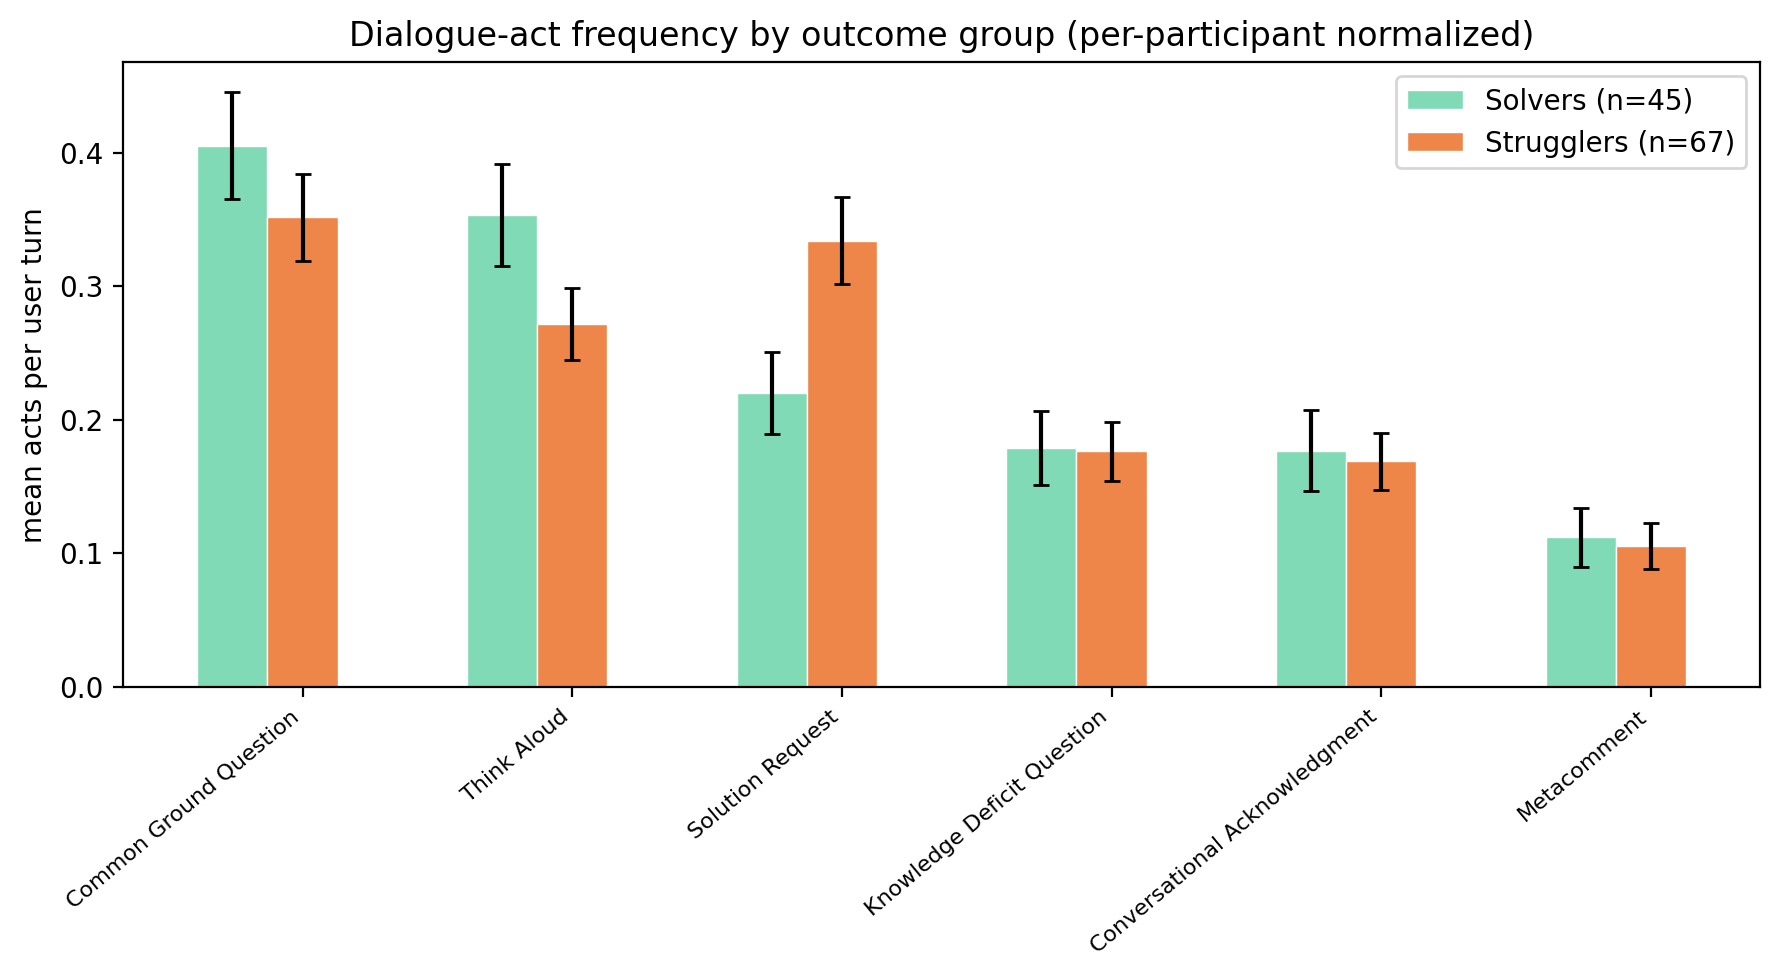

In [51]:
# Per-participant, per-turn rate of each dialogue act, averaged within group.
turns_per_pid = df.groupby("pid")["utt_ind"].nunique()          # user turns per participant
acts_df = df.dropna(subset=["utt_type"])

cnt = acts_df.groupby(["pid", "utt_type"]).size().rename("n").reset_index()
cnt["rate"] = cnt["n"] / cnt["pid"].map(turns_per_pid)

# participants x acts table of rates (0 where a participant never used that act);
# reindex over ALL pids so participants with no coded acts still count as zeros
rate_tbl = cnt.pivot_table(index="pid", columns="utt_type", values="rate", fill_value=0)
rate_tbl = rate_tbl.reindex(sorted(df["pid"].unique()), fill_value=0)
rate_tbl["outcome"] = rate_tbl.index.map(group_of)

acts_order = rate_tbl.drop(columns="outcome").sum().sort_values(ascending=False).index.tolist()
grp_mean = rate_tbl.groupby("outcome")[acts_order].mean()
grp_sem = rate_tbl.groupby("outcome")[acts_order].sem()
n_by = rate_tbl["outcome"].value_counts()

GRP = [("won", "#81dab6"), ("lost", "#ef8649")]
DISP = {"won": "Solvers", "win": "Solvers", "lost": "Strugglers"}
fig, ax = plt.subplots(figsize=(max(9, 0.9 * len(acts_order) + 3), 5))
x = np.arange(len(acts_order)); w = 0.26
for gi, (g, col) in enumerate(GRP):
    ax.bar(x + (gi - 1) * w, grp_mean.loc[g], w, yerr=grp_sem.loc[g], capsize=3,
           color=col, label=f"{DISP.get(g, g)} (n={n_by.get(g, 0)})", edgecolor="white", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(acts_order, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("mean acts per user turn")
ax.set_title("Dialogue-act frequency by outcome group (per-participant normalized)")
ax.legend(); plt.tight_layout(); plt.show()

### How far apart the two outcomes sit (dumbbell)

One row per dialogue act: a dot for **Solvers** (green, score ≥ 2) and **Strugglers** (red), each = that group's **mean share of a participant's acts (%)**, joined by a gray bar whose length is the gap. **Longer bar = the act separates Solvers from Strugglers more.** Sorted with the biggest separators on top (n per group is in the legend; treat small gaps as noise).

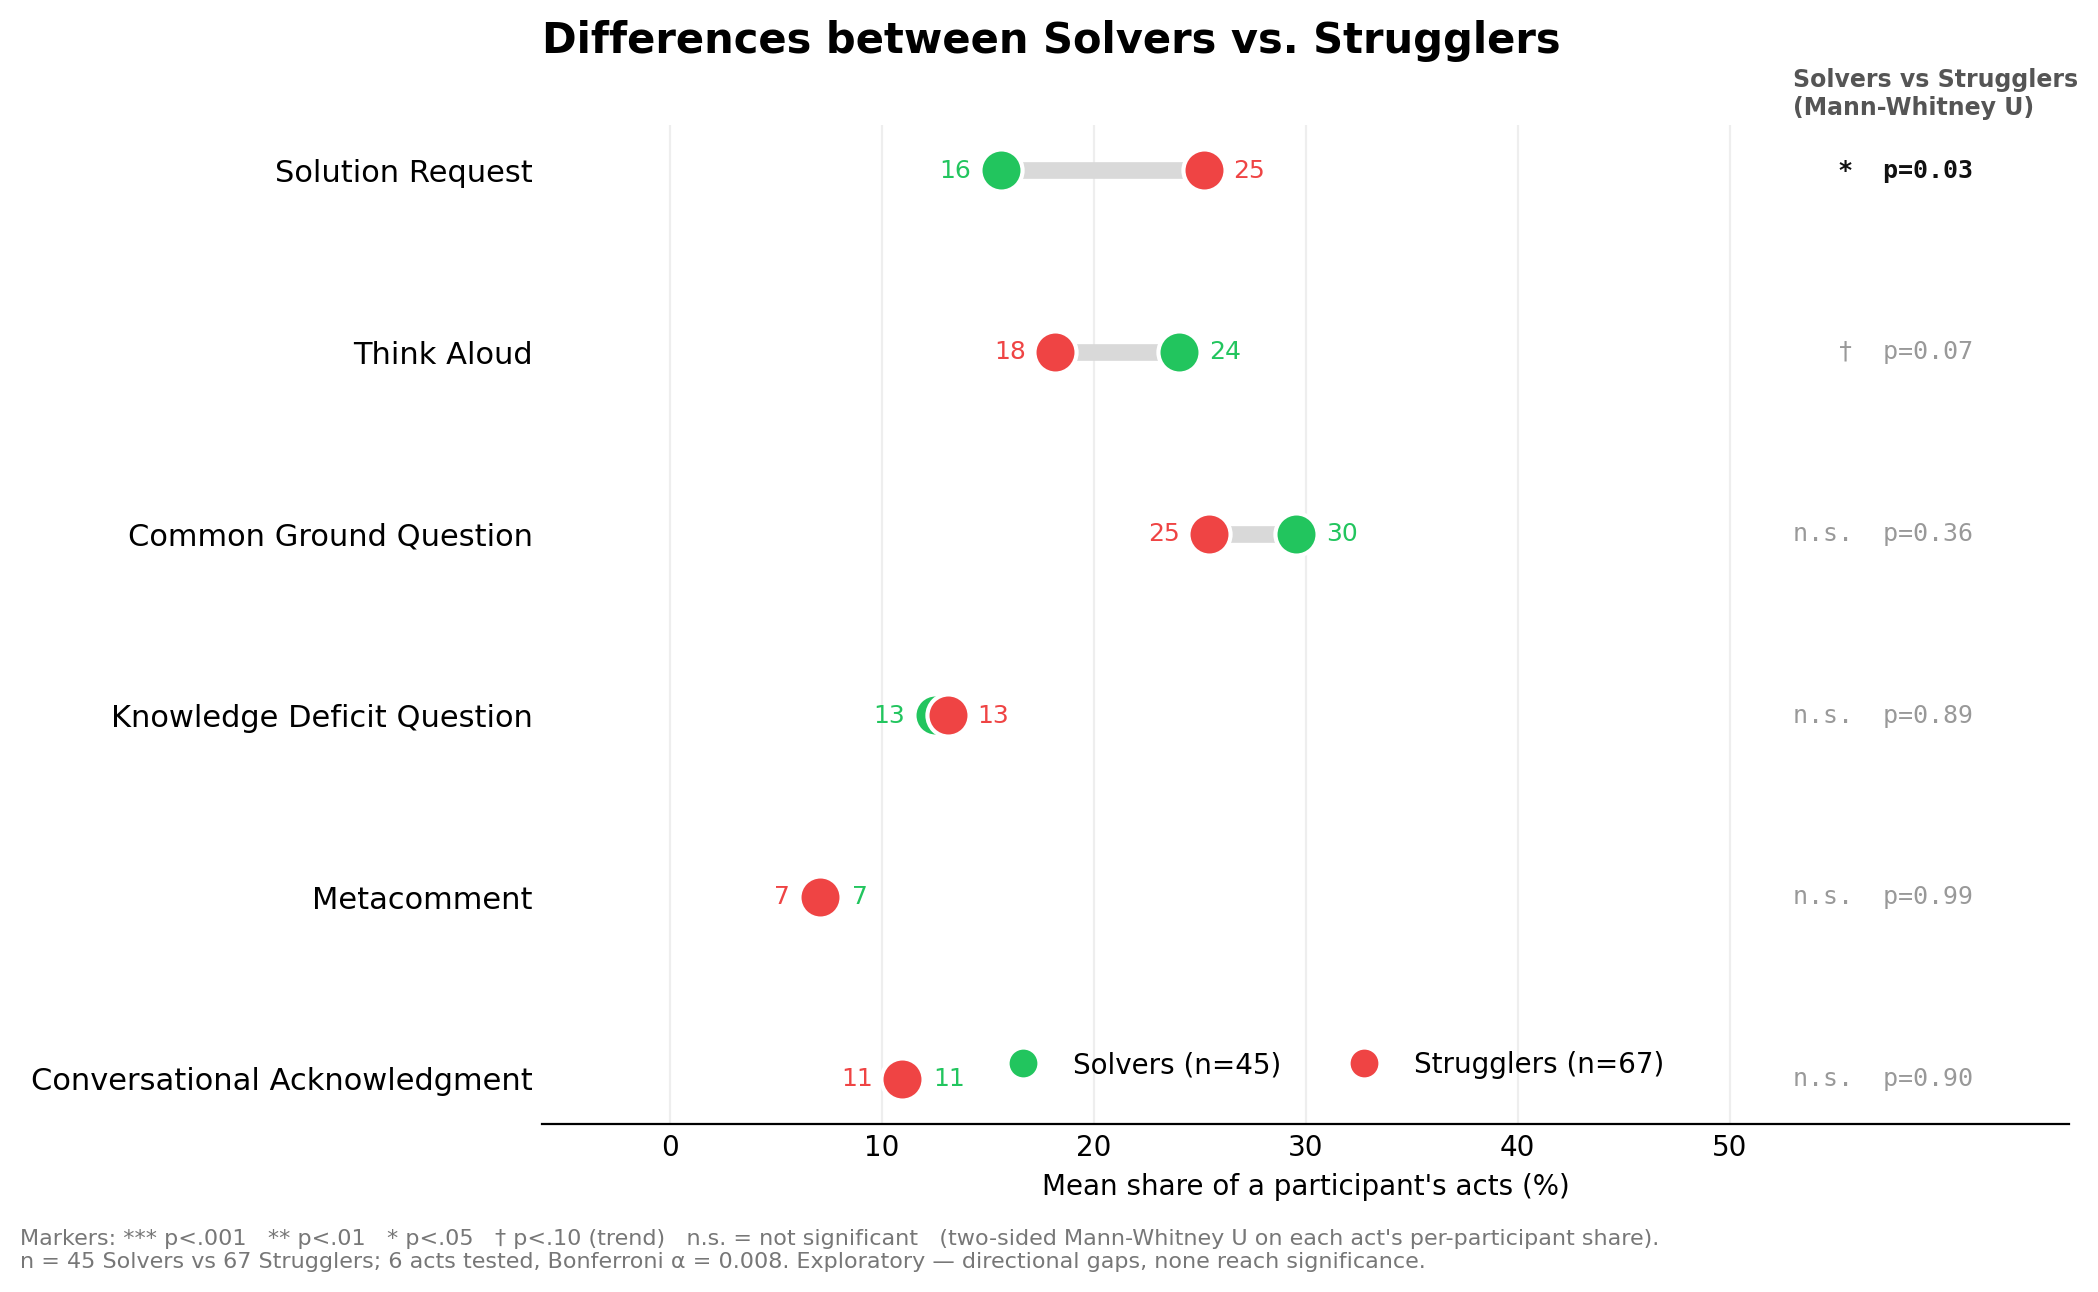

In [52]:
# Dumbbell: won vs lost separation on each dialogue act (+ significance markers).
# metric = mean share of a participant's acts (%). Labels sit on the OUTER side of
# each dot (smaller->left, larger->right) so they never overlap when dots are close.
# Right-hand column: Mann-Whitney U p-value per act (won vs lost share) + stars.
# Population is unchanged: good_pid (won, score>=2) vs bad_pid (lost) -- the original set.
from scipy.stats import mannwhitneyu
import matplotlib.transforms as mtransforms

LAB = [("Solvers", good_pid, "#22c55e"), ("Strugglers", bad_pid, "#ef4444")]
acts_all = df.dropna(subset=["utt_type"])
tot = acts_all.groupby("pid").size()
cnt = (acts_all.groupby(["pid", "utt_type"]).size().unstack(fill_value=0)
         .reindex(sorted(df["pid"].unique()), fill_value=0))
share = 100 * cnt.div(tot, axis=0).fillna(0)                 # pid x act (% of that pid's acts)

won_ids = [p for p in good_pid if p in share.index]          # score >= 2
lost_ids = [p for p in bad_pid if p in share.index]

def gmean(pids, a):
    idx = [p for p in pids if p in share.index]
    return share.loc[idx, a].mean()

def mwu_p(a):
    _, p = mannwhitneyu(share.loc[won_ids, a].values,
                        share.loc[lost_ids, a].values, alternative="two-sided")
    return p

def sig_mark(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    if p < 0.10:  return "†"                            # dagger = trend
    return "n.s."

acts = sorted(share.columns, key=lambda a: abs(gmean(good_pid, a) - gmean(bad_pid, a)), reverse=True)
y = np.arange(len(acts))
PAD = 1.4                                                     # horizontal gap between dot and its label
alpha_bonf = 0.05 / len(acts)                                # multiple-comparison threshold

fig, ax = plt.subplots(figsize=(10.5, 0.7 * len(acts) + 2))
XR = max(66, share.mean().max() + 22)                        # room for the significance column
SIG_X = XR - 13                                              # left edge of the p-value column
for yi, a in zip(y, acts):
    ranked = sorted(LAB, key=lambda t: gmean(t[1], a))       # ascending by value
    (lo_lab, lo_p, lo_c), (hi_lab, hi_p, hi_c) = ranked
    lo, hi = gmean(lo_p, a), gmean(hi_p, a)
    ax.hlines(yi, lo, hi, color="#d9d9d9", lw=6, zorder=1, capstyle="round")
    for lab, pids, col in LAB:
        ax.scatter(gmean(pids, a), yi, s=230, color=col, edgecolor="white", lw=1.5, zorder=3)
    ax.text(lo - PAD, yi, f"{lo:.0f}", ha="right", va="center", fontsize=9, color=lo_c)   # smaller -> left
    ax.text(hi + PAD, yi, f"{hi:.0f}", ha="left", va="center", fontsize=9, color=hi_c)    # larger  -> right
    # significance marker (Mann-Whitney U, won vs lost share)
    p = mwu_p(a)
    is_sig = p < 0.05
    ax.text(SIG_X, yi, f"{sig_mark(p):>4}  p={p:.2f}", ha="left", va="center", fontsize=9,
            family="monospace", color=("#111" if is_sig else "#999"),
            fontweight=("bold" if is_sig else "normal"))
ax.set_yticks(y); ax.set_yticklabels(acts, fontsize=11)
ax.invert_yaxis()
ax.set_xlim(-6, XR)
ax.set_xticks([t for t in range(0, 51, 10)])                 # ticks span the data range only
ax.set_xlabel("Mean share of a participant's acts (%)")
ax.set_title("Differences between Solvers vs. Strugglers", fontsize=15, fontweight="bold", loc="left", pad=26)
# significance-column header (data x, axes-fraction y so it sits just above the top row)
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
ax.text(SIG_X, 1.005, "Solvers vs Strugglers\n(Mann-Whitney U)", transform=trans, ha="left", va="bottom",
        fontsize=8.5, color="#555", fontweight="bold")
ax.grid(axis="x", color="#eee", zorder=0); ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)
handles = [plt.Line2D([0], [0], marker="o", ls="", ms=11, mfc=col, mec="white",
                      label=f"{lab} (n={len([p for p in pids if p in share.index])})")
           for lab, pids, col in LAB]
ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=10, ncol=2,
          bbox_to_anchor=(0.28, 0.02))
fig.text(0.01, -0.03,
         f"Markers: *** p<.001   ** p<.01   * p<.05   † p<.10 (trend)   n.s. = not significant   "
         f"(two-sided Mann-Whitney U on each act's per-participant share).\n"
         f"n = {len(won_ids)} Solvers vs {len(lost_ids)} Strugglers; {len(acts)} acts tested, "
         f"Bonferroni α = {alpha_bonf:.3f}. Exploratory — directional gaps, none reach significance.",
         fontsize=8, color="#777", ha="left")
plt.tight_layout(); plt.show()


### Dialogue acts vs. transfer outcome (scatter)

One point per participant instead of two group means: **x** = the share of the participant's R1 turns that carry that act (all turns in the denominator, unlabelled ones included), **y** = their unaided R2+R3 outcome (total final margin by default; flip `Y_METRIC` to `"rate"` for the pooled optimal-move rate). Dashed line = the win/loss boundary. Panels are sorted by |Spearman rho|, and the fit line is drawn for the eye only — with this n and 6 acts, read the p-values as exploratory.

Holm-Bonferroni over 2 act(s) [focal]: Solution Request, Think Aloud
  Think Aloud                  rho=+0.37  p_raw=0.0001  p_holm=0.0002  95% CI [+0.20, +0.51]  SE_boot=0.081  p_boot=0.0000  (10000/10000 reps)
  Solution Request             rho=-0.23  p_raw=0.0184  p_holm=0.0184  95% CI [-0.40, -0.03]  SE_boot=0.095  p_boot=0.0208  (10000/10000 reps)
  CI/SE from 10000 participant-level bootstrap resamples (seed 0); n=108 participants


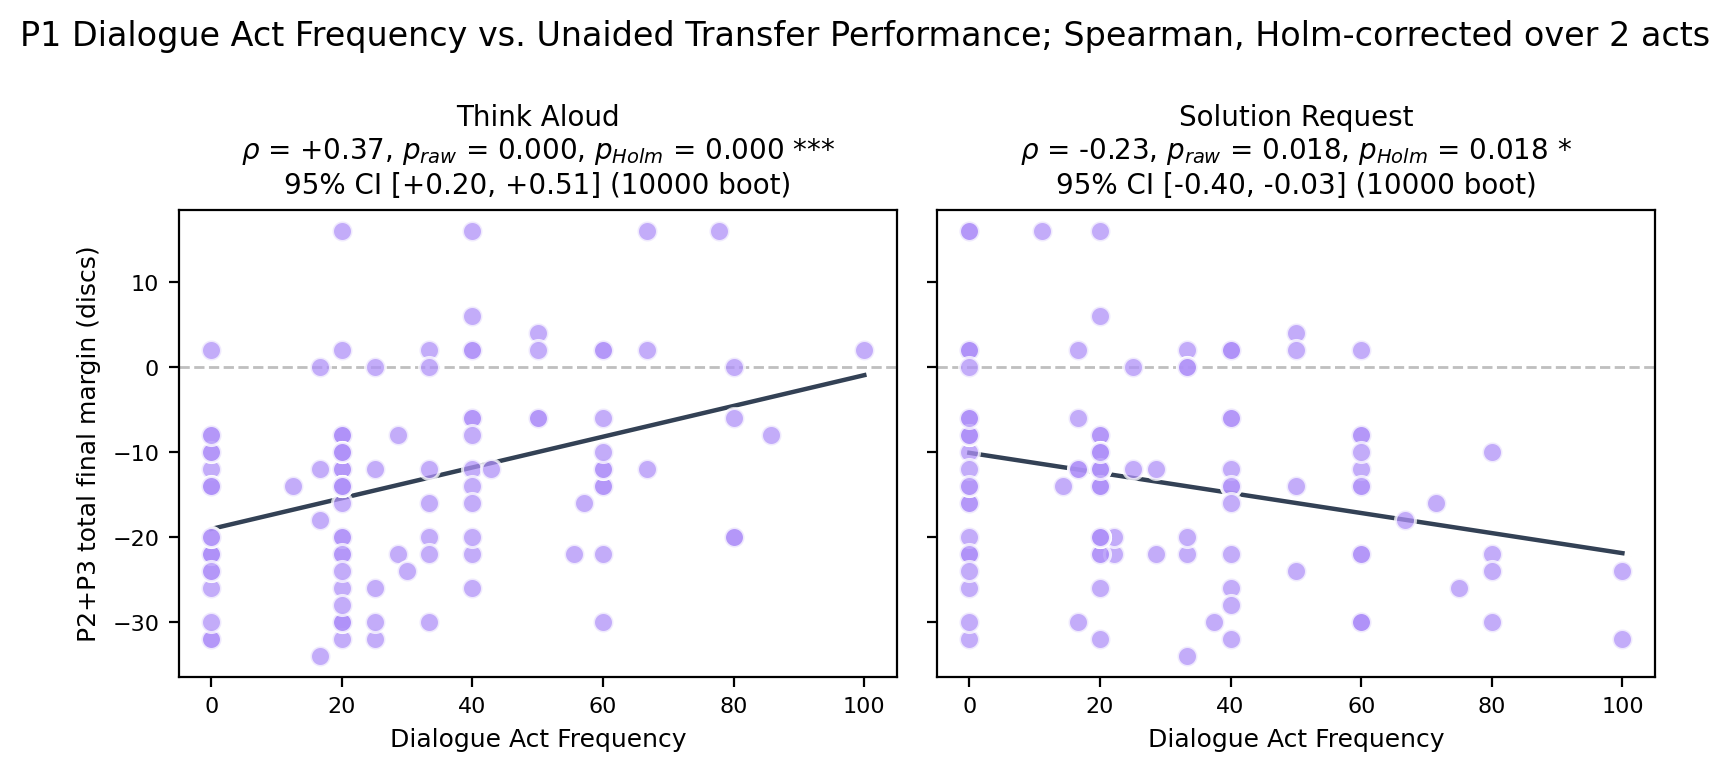

4 annotated participants have no margin (transfer block incomplete or timed out): 5b3e2334, 6082ab16, 673ce711, 698dee55


In [53]:
# --- Dialogue act vs. continuous outcome: scatter, focal acts only ---------------
# Replaces the Solvers/Strugglers dichotomy with the underlying continuum: every
# participant is one point, so no threshold is imposed and the spread inside each
# group stays visible. x = the share of the participant's R1 TURNS that carry the
# act; y = a continuous R2+R3 outcome.
#
# Y_METRIC:
#   "margin" -- total final disc margin over the two unaided puzzles (R2 + R3).
#               Signed discs, the DV the OLS cell below uses. Needs both rounds
#               FINISHED, so timed-out rounds drop out (no margin exists for a
#               position at the buzzer).
#   "rate"   -- pooled optimal-move rate across R2+R3, the measure the group split
#               is cut from. Keeps timed-out rounds.
#
# Only the two focal acts are plotted (FOCAL_ACTS), and the p-values are corrected
# for multiple comparisons with Holm-Bonferroni over those two. The family is the
# two acts, not all six, because the Connect-Four experiment that precedes this one
# already singled out Think Aloud and Solution Request as the acts that separated
# outcome groups -- the other four are carried along descriptively, not tested here.
# FAMILY = "all" widens the correction back to every act present in the annotations
# if the two-act family ever needs to be justified against the exploratory version.
import csv
from scipy import stats as _st

Y_METRIC = "margin"          # "margin" | "rate"
FOCAL_ACTS = ["Think Aloud", "Solution Request"]
FAMILY = "focal"             # "focal" (the two prior-hypothesis acts) | "all"
N_BOOT = 10000               # bootstrap replicates for rho's CI (0 = skip)
CI_LEVEL = 95                # percentile-CI coverage, %
BOOT_SEED = 0                # fixed so the printed CIs are reproducible

# --- outcome, straight from scores.csv (source of truth; the oth_score_*.json
# summaries are missing for any round that hit the clock) ------------------------
_sc = list(csv.DictReader(open("scores.csv")))
_tr = {}
for _r in _sc:
    if _r["round"] in ("R2", "R3"):
        _tr.setdefault(_r["pid"], []).append(_r)
if Y_METRIC == "margin":
    outcome = {p: sum(int(r["margin"]) for r in v)
               for p, v in _tr.items() if len(v) == 2 and all(r["margin"] for r in v)}
    ylab, yline = "P2+P3 total final margin (discs)", 0
elif Y_METRIC == "disc":
    outcome = {p: sum(float(r["disc_loss_per_decision"]) for r in v)
                   for p, v in _tr.items() if len(v) == 2 and all(r["disc_loss_per_decision"] for r in v)}
    ylab, yline = "P2+P3 disc loss per decision (discs)", 0
else:
    outcome = {p: float(v[0]["transfer_rate"]) for p, v in _tr.items()
               if len(v) == 2 and v[0]["transfer_rate"]}
    ylab, yline = "pooled optimal-move rate (P2+P3)", 0.6

# --- predictor: % of a participant's TURNS that carry this act ------------------
# Denominator = ALL of that participant's turns, including turns that got no act
# label, matching the OLS cell below. A turn labelled with the same act twice
# still counts once (nunique on the turn index), so each column is a clean
# "share of turns where this act appeared" and columns can exceed 100% only in
# aggregate across acts, never within one.
_acts_all = df.dropna(subset=["utt_type"])
_turns = df.groupby("pid")["utt_ind"].nunique()
_hits = (_acts_all.groupby(["pid", "utt_type"])["utt_ind"].nunique().unstack(fill_value=0)
           .reindex(sorted(df["pid"].unique()), fill_value=0))
share = 100 * _hits.div(_turns, axis=0).fillna(0)

pids = [p for p in share.index if p in outcome]
y = np.array([outcome[p] for p in pids], dtype=float)

def _rho(a):
    return _st.spearmanr(share.loc[pids, a].values, y)

def _boot_rho(a, n_boot=N_BOOT, seed=BOOT_SEED, level=CI_LEVEL):
    """Nonparametric bootstrap for Spearman rho: resample PARTICIPANTS (the (x, y)
    pairs) with replacement, recompute rho, and read the interval off the replicate
    distribution. Case resampling is the right unit here -- each participant is one
    independent observation, and it keeps the x/y pairing intact.

    Returns (lo, hi, se, p_boot, n_ok):
      lo/hi   percentile CI at `level`. This is what to report alongside rho: at
              n~30 rho's sampling distribution is skewed and bounded at +-1, so the
              CI carries the uncertainty far better than the p-value alone.
      se      SD of the replicates.
      p_boot  2 x the share of replicates on the far side of 0 from the point
              estimate (capped at 1) -- a rough two-sided sign check on the
              bootstrap distribution, NOT a replacement for the exact test, so the
              Holm correction below still runs on p_raw.
      n_ok    replicates that survived (a resample can leave x or y constant, which
              makes rho undefined; those are dropped).

    rho is computed as Pearson on average ranks (identical to scipy's spearmanr,
    ties included) so all replicates evaluate in one vectorized pass.
    """
    x = share.loc[pids, a].values.astype(float)
    n = len(x)
    if not n_boot or n < 3:
        return (np.nan,) * 4 + (0,)
    idx = np.random.default_rng(seed).integers(0, n, size=(n_boot, n))
    rx = _st.rankdata(x[idx], axis=1)
    ry = _st.rankdata(y[idx], axis=1)
    rx = rx - rx.mean(axis=1, keepdims=True)
    ry = ry - ry.mean(axis=1, keepdims=True)
    den = np.sqrt((rx ** 2).sum(axis=1) * (ry ** 2).sum(axis=1))
    reps = np.divide((rx * ry).sum(axis=1), den,
                     out=np.full(n_boot, np.nan), where=den > 0)
    reps = reps[np.isfinite(reps)]
    if reps.size == 0:
        return (np.nan,) * 4 + (0,)
    lo, hi = np.percentile(reps, [(100 - level) / 2, 100 - (100 - level) / 2])
    point = _rho(a).statistic
    tail = (reps <= 0).mean() if point > 0 else (reps >= 0).mean()
    return lo, hi, reps.std(ddof=1), min(1.0, 2 * tail), reps.size

def holm(pvals):
    """Holm-Bonferroni step-down adjusted p-values (monotone, capped at 1)."""
    m = len(pvals)
    order = sorted(range(m), key=lambda i: pvals[i])
    adj, running = [0.0] * m, 0.0
    for rank, i in enumerate(order):
        running = max(running, (m - rank) * pvals[i])
        adj[i] = min(1.0, running)
    return adj

# family of tests the correction is taken over, then the two panels drawn from it
fam_acts = (list(share.columns) if FAMILY == "all"
            else [a for a in FOCAL_ACTS if a in share.columns])
fam_raw = [_rho(a).pvalue for a in fam_acts]
p_adj = dict(zip(fam_acts, holm(fam_raw)))

acts_s = [a for a in FOCAL_ACTS if a in share.columns]
_missing_acts = [a for a in FOCAL_ACTS if a not in share.columns]
if _missing_acts:
    print(f"focal acts absent from the annotations: {', '.join(_missing_acts)}")

print(f"Holm-Bonferroni over {len(fam_acts)} act(s) [{FAMILY}]: "
      f"{', '.join(sorted(fam_acts))}")
boot = {a: _boot_rho(a) for a in acts_s}
for a in acts_s:
    r = _rho(a)
    lo, hi, se, p_b, n_ok = boot[a]
    print(f"  {a:<28} rho={r.statistic:+.2f}  p_raw={r.pvalue:.4f}  "
          f"p_holm={p_adj[a]:.4f}  "
          f"{CI_LEVEL}% CI [{lo:+.2f}, {hi:+.2f}]  SE_boot={se:.3f}  "
          f"p_boot={p_b:.4f}  ({n_ok}/{N_BOOT} reps)")
print(f"  CI/SE from {N_BOOT} participant-level bootstrap resamples "
      f"(seed {BOOT_SEED}); n={len(pids)} participants")

ncol = len(acts_s)
fig, axes = plt.subplots(1, ncol, figsize=(4.1 * ncol, 3.9),
                         sharey=True, squeeze=False)
for ax, a in zip(axes.ravel(), acts_s):
    x = share.loc[pids, a].values
    rho, p = _rho(a)
    pa = p_adj[a]
    # colour only encodes the sign of the outcome, so the win/loss split stays
    # legible without reintroducing a group variable
    ax.scatter(x, y, s=52, c="#AF91F8",
               alpha=0.75, edgecolor="white", lw=1.1, zorder=3)
    if x.std() > 0:
        b, a0 = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 50)
        ax.plot(xs, a0 + b * xs, color="#334155", lw=1.6, zorder=2)
    ax.axhline(yline, color="0.75", lw=1, ls="--", zorder=1)
    # stars follow the CORRECTED p; the raw p is kept alongside for reference
    star = ("***" if pa < .001 else "**" if pa < .01 else "*" if pa < .05
            else "†" if pa < .10 else "n.s.")
    lo, hi, _se, _pb, _nok = boot[a]
    ci = ("" if not np.isfinite(lo)
          else f"\n{CI_LEVEL}% CI [{lo:+.2f}, {hi:+.2f}] ({N_BOOT} boot)")
    ax.set_title(f"{a}\n$\\rho$ = {rho:+.2f}, $p_{{raw}}$ = {p:.3f}, "
                 f"$p_{{Holm}}$ = {pa:.3f} {star}{ci}", fontsize=10)
    ax.set_xlabel("Dialogue Act Frequency", fontsize=9)
    ax.tick_params(labelsize=8)
axes[0, 0].set_ylabel(ylab, fontsize=9)
fig.suptitle(f"P1 Dialogue Act Frequency vs. Unaided Transfer Performance; "
             f"Spearman, Holm-corrected over {len(fam_acts)} acts", fontsize=12)
plt.tight_layout(); plt.show()

_missing = [p for p in share.index if p not in outcome]
if _missing:
    print(f"{len(_missing)} annotated participants have no {Y_METRIC} "
          f"(transfer block incomplete or timed out): "
          f"{', '.join(sorted(p[:8] for p in _missing))}")


### Solvers vs Strugglers: t-test per dialogue act

Independent (Welch, unequal-variance) t-test on each act's **share of a participant's acts (%)**, Solvers (score ≥ 2) vs Strugglers. Participants who never used an act count as 0%. Also reports Mann-Whitney U (nonparametric — safer here since shares are bounded and zero-heavy) and Cohen's d (effect size).

*Caveats:* n = 17 / 15, and testing ~6 acts means multiple comparisons — the Bonferroni threshold is α = 0.05 / (#acts). Treat this as exploratory; with this n, expect little to survive correction.

In [54]:
# Permutation test (+ Mann-Whitney, Cohen's d) on per-participant act share, won vs lost.
# Swapped from Welch's t-test: these shares are bounded, zero-heavy proportions from tiny
# per-participant act counts (~1-8), so at this n a label-permutation test on the mean
# difference is more defensible than a t-test (no normality assumption).
from scipy import stats

acts_all = df.dropna(subset=["utt_type"])
tot = acts_all.groupby("pid").size()
cnt = (acts_all.groupby(["pid", "utt_type"]).size().unstack(fill_value=0)
         .reindex(sorted(df["pid"].unique()), fill_value=0))
share = 100 * cnt.div(tot, axis=0).fillna(0)                 # pid x act (% of that pid's acts)
won_ids = [p for p in good_pid if p in share.index]         # score >= 2
lost_ids = [p for p in bad_pid if p in share.index]

# Combined "reasoning" acts proportion (share of a participant's acts that are any of these).
REASONING_ACTS = ["Think Aloud"]
reasoning_share = share[[a for a in REASONING_ACTS if a in share.columns]].sum(axis=1)

# Variables to test: each individual act's share, plus the combined reasoning proportion.
# variables = [(a, share[a]) for a in share.columns]
variables = []
variables.append(("Reasoning (CGQ+TA)", reasoning_share))

def cohend(x, z):
    nx, nz = len(x), len(z)
    sp = np.sqrt(((nx - 1) * x.var(ddof=1) + (nz - 1) * z.var(ddof=1)) / (nx + nz - 2))
    return (x.mean() - z.mean()) / sp if sp > 0 else np.nan

def perm_test(x, z, n_perm=20000, seed=0):
    """Two-sided permutation test on the difference in group means (label shuffling)."""
    obs = x.mean() - z.mean()
    pooled = np.concatenate([x, z]); nx = len(x)
    rng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        d = perm[:nx].mean() - perm[nx:].mean()
        if abs(d) >= abs(obs) - 1e-12:
            ge += 1
    return obs, (ge + 1) / (n_perm + 1)                      # +1 = the observed labeling

rows = []
for a, series in variables:
    x, z = series.loc[won_ids].values, series.loc[lost_ids].values
    obs, p_perm = perm_test(x, z)                            # permutation (mean diff)
    _, pu = stats.mannwhitneyu(x, z, alternative="two-sided")
    rows.append((a, x.mean(), z.mean(), obs, p_perm, pu, cohend(x, z)))
rows.sort(key=lambda r: r[4])                                # by permutation p

alpha_bonf = 0.05 / len(rows)
print(f"Permutation test (mean diff, 20k shuffles): Solvers (n={len(won_ids)}) vs Strugglers (n={len(lost_ids)})   "
      f"Bonferroni alpha = {alpha_bonf:.4f}\n")
print(f"{'act':>28} {'Solv%':>6} {'Strug%':>6} {'diff':>6} {'perm_p':>7} {'MWU_p':>7} {'d':>6}")
for a, w, l, dff, p, pu, d in rows:
    star = "*" if p < alpha_bonf else ("." if p < 0.05 else " ")
    print(f"{a:>28} {w:6.1f} {l:6.1f} {dff:+6.1f} {p:7.3f} {pu:7.3f} {d:+6.2f} {star}")
print("\n  * p < Bonferroni alpha    . p < 0.05 (uncorrected)")


Permutation test (mean diff, 20k shuffles): Solvers (n=45) vs Strugglers (n=67)   Bonferroni alpha = 0.0500

                         act  Solv% Strug%   diff  perm_p   MWU_p      d
          Reasoning (CGQ+TA)   24.0   18.2   +5.8   0.043   0.069  +0.39 *

  * p < Bonferroni alpha    . p < 0.05 (uncorrected)


In [55]:
df.to_csv("participant_utterances.csv", index=False)

# AI-assistant rating by outcome group (Solvers / Strugglers)

From `assistant_helpfulness.csv` — the post-round survey on the AI assistant. Two items on a 5-point Likert (strongly disagree=1 … strongly agree=5):

- **consistent-with-intent** — "responses were consistent with the intentions of my questions"
- **easy-to-use** — "the AI assistant was easy to use"

Each participant is tagged with their Round-2 outcome label (Solvers / Strugglers). Duplicate submissions are resolved to the participant's **first** (Round-1) response; respondents not among our 35 both-round completers are unlabeled and excluded from group means.

survey respondents: 112   labeled (in our 35 completers): 109
labeled completers with NO survey row (3): 64135e56[Strugglers], 65c272d0[Strugglers], ovieComm[Solvers]

 participant       group  intent  ease
558955ebfdf9  Strugglers       4     4
577d0ad6adbc  Strugglers       5     5
59b044b4d98a  Strugglers       4     4
5a4cc0ecac41  Strugglers       4     5
5b0f33dd1e55  Strugglers       4     4
5b2cf6a10ec8  Strugglers       4     4
5b5341ddd834  Strugglers       4     4
5bcda2ee6fd7  Strugglers       5     4
5c1976c90d57  Strugglers       5     5
5c5ca0ce4ee8  Strugglers       2     4
5c6088630112  Strugglers       5     5
5c852c65f8e5  Strugglers       5     5
5c9224087a70  Strugglers       4     4
5c9d88bb2b3c  Strugglers       3     4
5d6ac7e17658  Strugglers       4     5
5d7ebf9e9390  Strugglers       3     4
5dcf1031b039  Strugglers       1     4
5dde6f53fd5b  Strugglers       4     4
5e573ce57a25  Strugglers       3     4
5ea2e082eeb3  Strugglers       5     5
5efa455b7a38 

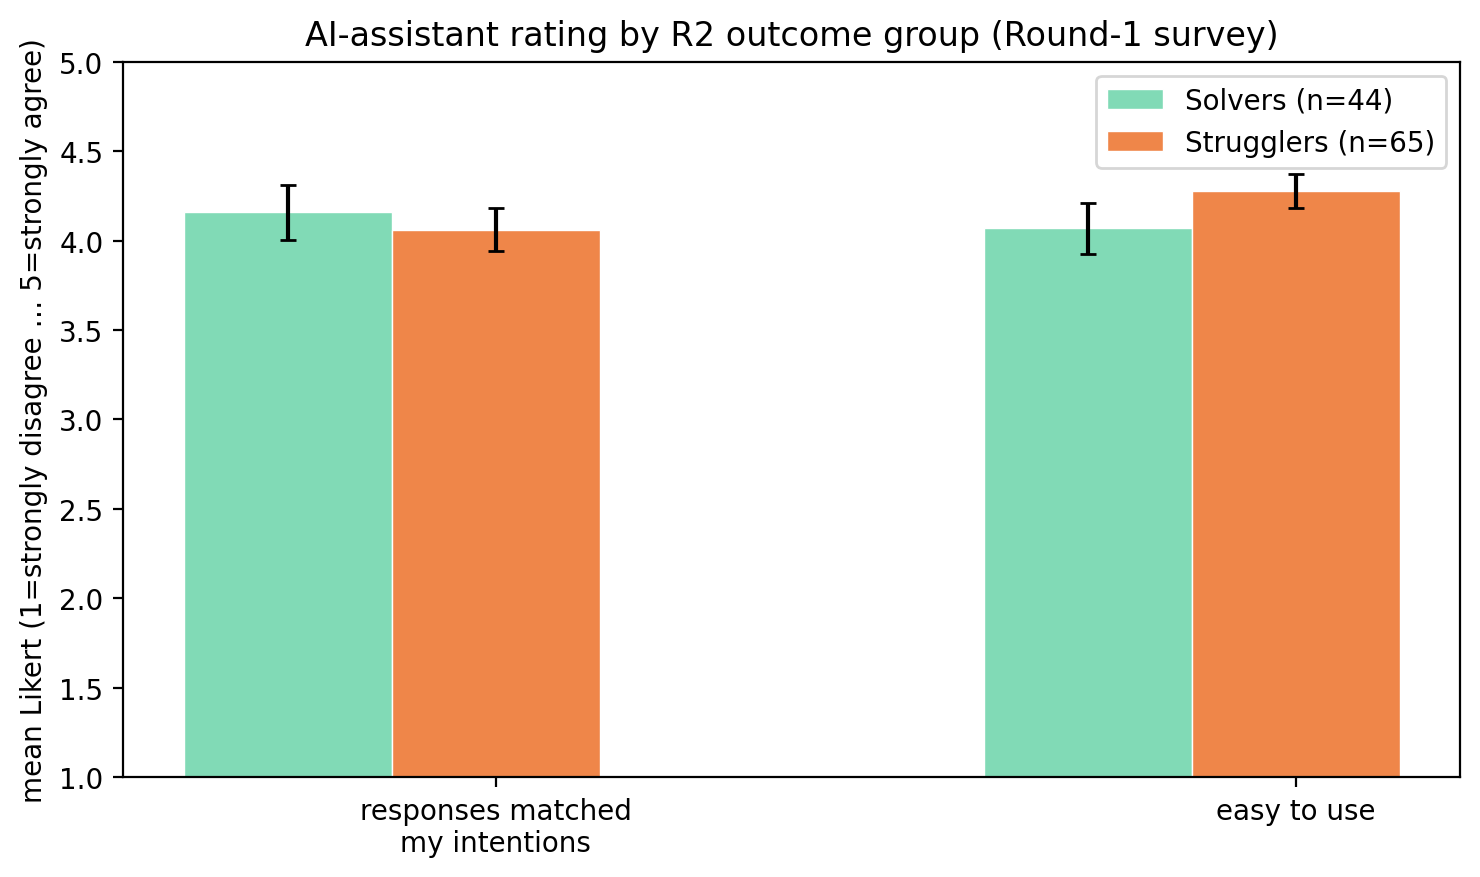

In [56]:
# --- Join assistant_helpfulness.csv with Solvers/Strugglers labels ---
import csv

LIKERT = {"strongly disagree": 1, "disagree": 2, "neutral": 3, "agree": 4, "strongly agree": 5}
GROUP_OF = {**{p: "won" for p in good_pid}, **{p: "win" for p in win_pid}, **{p: "lost" for p in bad_pid}}
DISP = {"won": "Solvers", "win": "Solvers", "lost": "Strugglers"}

rows = list(csv.DictReader(open("assistant_helpfulness_othello.csv")))
cols = list(rows[0].keys())
pid_col, intent_col, ease_col = cols[1], cols[2], cols[3]   # ID, "consistent with intentions", "easy to use"

# one record per participant = their FIRST (Round-1) submission
per_pid = {}
for r in rows:
    pid = r[pid_col].strip()
    if pid in per_pid:
        continue
    per_pid[pid] = {
        "intent": LIKERT.get(r[intent_col].strip().lower()),
        "ease":   LIKERT.get(r[ease_col].strip().lower()),
        "group":  GROUP_OF.get(pid),
    }

labeled = {p: v for p, v in per_pid.items() if v["group"]}
missing = sorted(set(GROUP_OF) - set(per_pid))          # labeled completers with no survey row
print(f"survey respondents: {len(per_pid)}   labeled (in our 35 completers): {len(labeled)}")
if missing:
    print(f"labeled completers with NO survey row ({len(missing)}): "
          + ", ".join(f"{p[:8]}[{DISP.get(GROUP_OF[p], GROUP_OF[p])}]" for p in missing))

# per-participant labeled table
print(f"\n{'participant':>12} {'group':>11} {'intent':>7} {'ease':>5}")
for pid, v in sorted(labeled.items(), key=lambda kv: (kv[1]["group"], kv[0])):
    print(f"{pid[:12]:>12} {DISP.get(v['group'], v['group']):>11} {str(v['intent']):>7} {str(v['ease']):>5}")

# group means + plot
GRP = [("won", "#81dab6"), ("lost", "#ef8649")]
METRICS = [("intent", "responses matched\nmy intentions"), ("ease", "easy to use")]
print()
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(METRICS)); w = 0.26
for gi, (grp, col) in enumerate(GRP):
    vs = [v for v in labeled.values() if v["group"] == grp]
    means = [np.mean([v[m] for v in vs if v[m] is not None]) for m, _ in METRICS]
    sems = [np.std([v[m] for v in vs if v[m] is not None]) / np.sqrt(sum(v[m] is not None for v in vs))
            for m, _ in METRICS]
    ax.bar(x + (gi - 1) * w, means, w, yerr=sems, capsize=3, color=col,
           label=f"{DISP.get(grp, grp)} (n={len(vs)})", edgecolor="white", lw=0.5)
    print(f"{DISP.get(grp, grp):>11} (n={len(vs)}):  intent {means[0]:.2f}   ease {means[1]:.2f}")
ax.set_xticks(x); ax.set_xticklabels([lbl for _, lbl in METRICS])
ax.set_ylim(1, 5); ax.set_ylabel("mean Likert (1=strongly disagree … 5=strongly agree)")
ax.set_title("AI-assistant rating by R2 outcome group (Round-1 survey)")
ax.legend(); plt.tight_layout(); plt.show()

## OLS: R1 reasoning-act engagement → R2 performance

Regress each R2 outcome on the share of a participant's R1 dialogue acts that are *reasoning* acts (Common Ground Question + Think Aloud + Knowledge-Deficit Question). Exploratory / single-predictor; IV is from the AI-assisted R1 conversation, DV from the unassisted R2.

In [57]:
# --- OLS: R1 reasoning-act engagement -> R2+R3 margin, net of GenAI use and R1 margin ---
# IV  : % of a participant's R1 TURNS that carry a "reasoning" act (REASONING_ACTS) --
#       numerator = turns with >= 1 such act, denominator = ALL of that participant's turns,
#       including turns that got no act label at all.
# COV : genai     -- self-reported GenAI usage frequency, ordinal 0..7 from demographics.json
#                    (GENAI_BINARY switches to the >= few_times_week split);
#       r1_margin -- final disc margin in the AI-assisted R1 game. Continuous here (unlike
#                    the Connect Four bands), so it enters directly as a prior-skill control.
# DV  : total final margin over the two unassisted rounds, R2 + R3.
# Models: M1 reasoning only (pre-specified) | M2 + genai | M3 + genai + r1_margin, with the
# full M3 coefficient table printed underneath. M2/M3 are exploratory. Margin is signed
# discs, so every coefficient reads as "discs of margin per one unit of the predictor".
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats as _stats

# REASONING_ACTS = ["Common Ground Question", "Think Aloud", "Knowledge Deficit Question"]
REASONING_ACTS = ["Think Aloud"]
SHOW_SUMMARY = False                                            # print fit.summary() for M3
GENAI_BINARY = False                                            # True -> 1 if >= few_times_week


# per-participant reasoning-act share = turns with a reasoning act / all turns.
# df is long (one row per turn x act, no-act turns kept as a single utt_type=None row),
# so turns are counted with nunique("utt_ind") -- a turn carrying two reasoning acts
# still counts once, and unlabelled turns stay in the denominator.
_turns = df.groupby("pid")["utt_ind"].nunique()                 # all turns, labelled or not
_hits = (df[df["utt_type"].isin(REASONING_ACTS)]
           .groupby("pid")["utt_ind"].nunique())                # turns with >= 1 reasoning act
reasoning_prop = (_hits.reindex(_turns.index, fill_value=0) / _turns).fillna(0)   # [0, 1]

GENAI_USAGE_OPTIONS = {"never": 0, "less_than_monthly": 1, "about_monthly": 2,
                       "few_times_month": 3, "weekly": 4, "few_times_week": 5,
                       "daily": 6, "several_times_day": 7}

# one row per participant: IV, covariates, DV (needs both unassisted rounds scored)
rows = []
for pid in reasoning_prop.index:
    f1 = RECORDINGS_BASE / pid / score_r1
    f2, f3 = RECORDINGS_BASE / pid / score_r2, RECORDINGS_BASE / pid / score_r3
    fd = RECORDINGS_BASE / pid / "demographics.json"
#     if json.load(open(fd))["skill_rating"] == "dont_know":
#         continue
    if not (f2.exists() and f3.exists()):
        continue
    m2 = json.load(open(f2)).get("final_margin")
    m3_ = json.load(open(f3)).get("final_margin")
    if m2 is None or m3_ is None:
        continue
    r1m = json.load(open(f1)).get("final_margin") if f1.exists() else None
    gv = json.load(open(fd)).get("genai_usage") if fd.exists() else None
    g = float(GENAI_USAGE_OPTIONS.get(gv, np.nan))              # nan when the item is blank
    if GENAI_BINARY and not np.isnan(g):
        g = float(g >= GENAI_USAGE_OPTIONS["few_times_week"])
    rows.append(dict(pid=pid, reasoning=float(reasoning_prop[pid]), genai=g,
                     r1_margin=(np.nan if r1m is None else float(r1m)),
                     r2_margin=float(m2), r3_margin=float(m3_), y=float(m2 + m3_)))
mdl = pd.DataFrame(rows).set_index("pid")

_nmiss = f"GenAI {int(mdl['genai'].isna().sum())}, R1 margin {int(mdl['r1_margin'].isna().sum())}"
print(f"analysis sample: n={len(mdl)}   missing covariates: {_nmiss} "
      f"(missing rows drop out of the models that use them)")
print(f"  {'reasoning share':<22} mean={mdl.reasoning.mean():7.3f} sd={mdl.reasoning.std(ddof=1):6.3f}"
      f"   [% of turns with {' / '.join(REASONING_ACTS)}]")
print(f"  {'genai usage':<22} mean={mdl.genai.mean():7.2f} sd={mdl.genai.std(ddof=1):6.2f}"
      + ("   [binary >= few/wk]" if GENAI_BINARY else "   [0-7 ordinal]"))
print(f"  {'R1 margin':<22} mean={mdl.r1_margin.mean():7.2f} sd={mdl.r1_margin.std(ddof=1):6.2f}"
      f"   [{mdl.r1_margin.min():.0f} .. {mdl.r1_margin.max():.0f}]")
print(f"  {'DV: R2+R3 margin':<22} mean={mdl.y.mean():7.2f} sd={mdl.y.std(ddof=1):6.2f}"
      f"   [{mdl.y.min():.0f} .. {mdl.y.max():.0f}]   "
      f"R2 {mdl.r2_margin.mean():+.1f} / R3 {mdl.r3_margin.mean():+.1f}")

def _row(label, fit):
    """One line per model: the focal reasoning slope plus fit stats."""
    b, se = fit.params.get("reasoning", np.nan), fit.bse.get("reasoning", np.nan)
    t, p = fit.tvalues.get("reasoning", np.nan), fit.pvalues.get("reasoning", np.nan)
    lo, hi = (fit.conf_int().loc["reasoning"] if "reasoning" in fit.params.index else (np.nan, np.nan))
    star = " *" if p < 0.05 else ("  ." if p < 0.10 else "")
    print(f"  {label:<26} {int(fit.nobs):>4} {b:+8.3f} {se:6.3f} {t:6.2f} {p:7.4f} "
          f"[{lo:+7.3f},{hi:+7.3f}] {fit.rsquared:6.3f} {fit.rsquared_adj:6.3f}{star}")

r, rp = _stats.pearsonr(mdl.reasoning, mdl.y); rho, rhop = _stats.spearmanr(mdl.reasoning, mdl.y)
print(f"\nR2+R3 total margin ~ R1 reasoning-act share   (bivariate: Pearson r={r:+.3f} p={rp:.4f} | "
      f"Spearman rho={rho:+.3f} p={rhop:.4f})")
print(f"  {'model':<26} {'n':>4} {'b_reason':>8} {'SE':>6} {'t':>6} {'p':>7} "
      f"{'95% CI':>17} {'R2':>6} {'adjR2':>6}")
_row("M1  reasoning", smf.ols("y ~ reasoning", mdl).fit())
_row("M2  + genai", smf.ols("y ~ reasoning + genai", mdl).fit())
m3 = smf.ols("y ~ reasoning + genai + r1_margin", mdl).fit()
_row("M3  + genai + R1 margin", m3)

print(f"\n  -- M3 coefficients (n={int(m3.nobs)}, discs of R2+R3 margin per unit) --")
print(f"  {'term':<14} {'coef':>8} {'SE':>6} {'t':>6} {'p':>7} {'95% CI':>19} {'beta':>6}")
_used = mdl.dropna(subset=["y", "reasoning", "genai", "r1_margin"])   # rows M3 actually fit
_sd = _used[["reasoning", "genai", "r1_margin"]].std(ddof=1)
for term in m3.params.index:
    lo, hi = m3.conf_int().loc[term]
    beta = (m3.params[term] * _sd[term] / _used.y.std(ddof=1)
            if term in _sd.index else np.nan)                   # standardized, for comparability
    star = " *" if m3.pvalues[term] < 0.05 else ("  ." if m3.pvalues[term] < 0.10 else "")
    print(f"  {term:<14} {m3.params[term]:+8.3f} {m3.bse[term]:6.3f} {m3.tvalues[term]:6.2f} "
          f"{m3.pvalues[term]:7.4f} [{lo:+8.3f},{hi:+8.3f}] "
          f"{'' if np.isnan(beta) else f'{beta:+6.3f}'}{star}")
print(f"  reasoning: a +0.10 shift in the {'/'.join(REASONING_ACTS)} turn share = "
      f"{0.10 * m3.params['reasoning']:+.2f} discs of R2+R3 margin (M3)")
if SHOW_SUMMARY:
    print(f"\n--- M3 ---\n{m3.summary()}\n")

print("\n  * p<0.05   . p<0.10   |  IV + covariates from R1 (AI-assisted), DV from unassisted R2+R3")
print("  M1 is the pre-specified model; M2/M3 are exploratory. r1_margin controls for prior skill,")
print("  but it is also downstream of the R1 conversation, so M3's b_reason is a lower bound.")

analysis sample: n=112   missing covariates: GenAI 0, R1 margin 0 (missing rows drop out of the models that use them)
  reasoning share        mean=  0.304 sd= 0.236   [% of turns with Think Aloud]
  genai usage            mean=   4.41 sd=  2.03   [0-7 ordinal]
  R1 margin              mean=  -8.75 sd= 15.92   [-30 .. 18]
  DV: R2+R3 margin       mean= -14.13 sd= 11.88   [-43 .. 16]   R2 -3.8 / R3 -10.4

R2+R3 total margin ~ R1 reasoning-act share   (bivariate: Pearson r=+0.368 p=0.0001 | Spearman rho=+0.356 p=0.0001)
  model                         n b_reason     SE      t       p            95% CI     R2  adjR2
  M1  reasoning               112  +18.517  4.467   4.15  0.0001 [ +9.664,+27.370]  0.135  0.127 *
  M2  + genai                 112  +18.773  4.448   4.22  0.0001 [ +9.957,+27.589]  0.152  0.136 *
  M3  + genai + R1 margin     112  +18.331  4.443   4.13  0.0001 [ +9.525,+27.137]  0.166  0.143 *

  -- M3 coefficients (n=112, discs of R2+R3 margin per unit) --
  term           

In [58]:
# --- Solvers vs Strugglers: IT-occupation & frequent-GenAI-use differences (Pearson chi-square) ---
# won = good_pid (high R2), lost = bad_pid (low R2). Two 2x2 tests. Binary splits keep
# cell counts high enough for the chi-square approximation (min-expected printed as a check).
from scipy import stats as _stats

# "few times a week and above" (weekly counts as INFREQUENT -- it's below few_times_week)
FREQUENT_GENAI = {"few_times_week", "daily", "several_times_day"}

def _demo(pids):
    out = []
    for pid in pids:
        f = RECORDINGS_BASE / pid / "demographics.json"
        if f.exists():
            out.append(json.load(open(f)))
    return out

_won, _lost = _demo(good_pid), _demo(bad_pid)

def _chi2_2x2(field, pred, label, pos_name, neg_name):
    def counts(rows):
        vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
        pos = sum(1 for v in vals if pred(v))
        return pos, len(vals) - pos, len(vals)
    wp, wn, wt = counts(_won)
    lp, ln, lt = counts(_lost)
    table = np.array([[wp, wn], [lp, ln]])
    chi2, p, dof, exp = _stats.chi2_contingency(table, correction=False)   # Pearson (no Yates)
    v = np.sqrt(chi2 / table.sum())                                        # Cramer's V (= phi for 2x2)
    print(f"\n{label}  (Pearson chi-square, 2x2)")
    print(f"  Solvers    (n={wt}): {pos_name}={wp} ({100*wp/wt:.0f}%)   {neg_name}={wn}")
    print(f"  Strugglers (n={lt}): {pos_name}={lp} ({100*lp/lt:.0f}%)   {neg_name}={ln}")
    print(f"  chi2={chi2:.2f}, dof={dof}, p={p:.4f}, Cramer's V={v:.2f}, "
          f"min expected={exp.min():.1f}{'  *significant' if p < 0.05 else ''}")
    if exp.min() < 5:
        print("  (min expected count < 5 -> chi-square approximate here; Fisher's exact would be safer)")

print(f"Solvers n={len(_won)}  |  Strugglers n={len(_lost)}")
_chi2_2x2("occupation", lambda v: v == "it",
          "IT vs non-IT occupation", "IT", "non-IT")
_chi2_2x2("genai_usage", lambda v: v in FREQUENT_GENAI,
          "Frequent (>= few times/week) vs infrequent GenAI use", "frequent", "infrequent")


Solvers n=45  |  Strugglers n=67

IT vs non-IT occupation  (Pearson chi-square, 2x2)
  Solvers    (n=45): IT=9 (20%)   non-IT=36
  Strugglers (n=67): IT=17 (25%)   non-IT=50
  chi2=0.44, dof=1, p=0.5091, Cramer's V=0.06, min expected=10.4

Frequent (>= few times/week) vs infrequent GenAI use  (Pearson chi-square, 2x2)
  Solvers    (n=45): frequent=27 (60%)   infrequent=18
  Strugglers (n=67): frequent=41 (61%)   infrequent=26
  chi2=0.02, dof=1, p=0.8991, Cramer's V=0.01, min expected=17.7


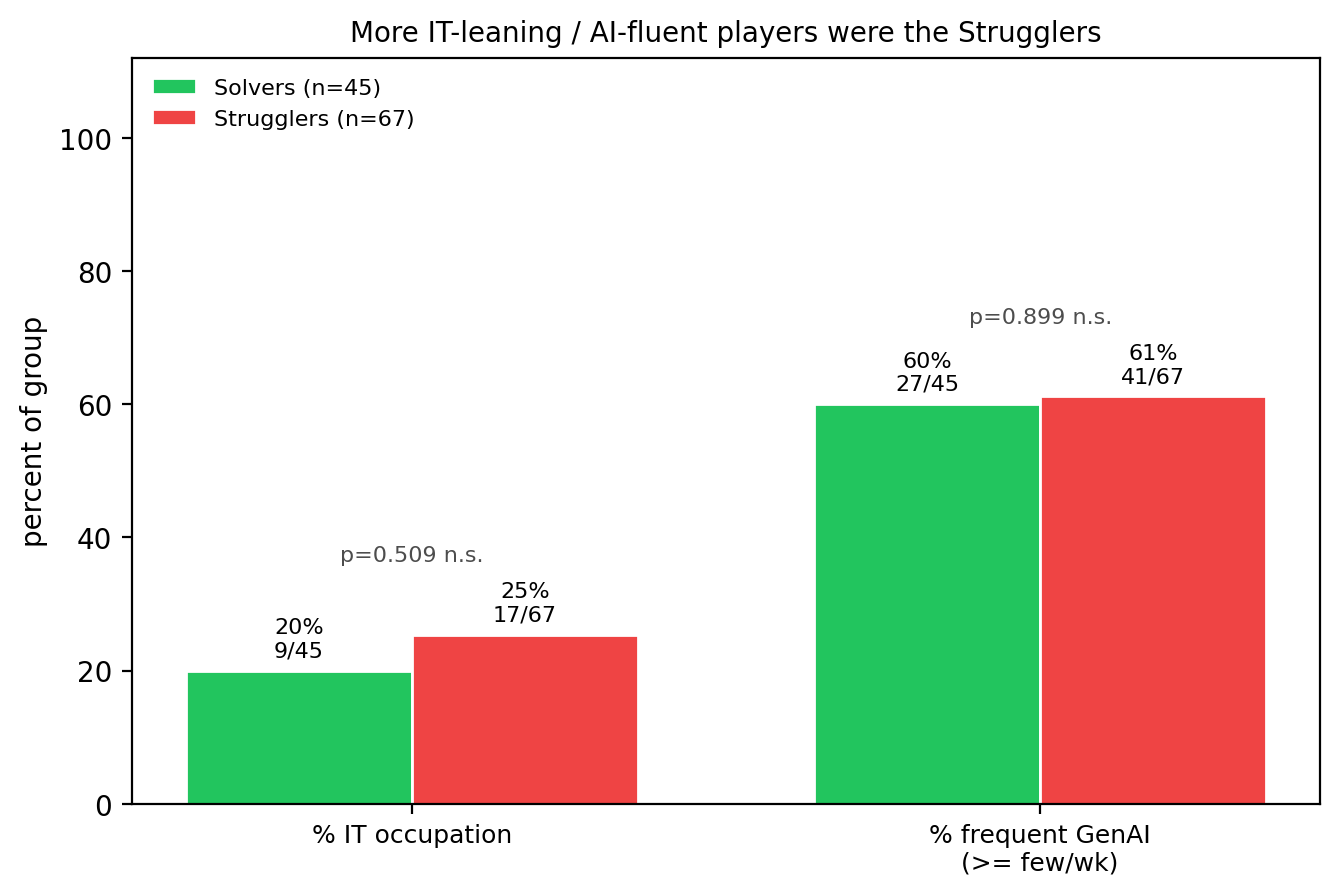

In [59]:
# --- Binary demographic splits: grouped single bars ---
# Same two comparisons the chi-square cell above tests (Solvers vs Strugglers), showing
# ONLY the informative category (% IT, % frequent GenAI user) so the takeaway reads fast.
# Reuses _won/_lost/FREQUENT_GENAI/_stats so bars and p-values match demo_won_lost_chi2.

METRICS = [
    ("% IT occupation", "occupation", lambda v: v == "it"),
    ("% frequent GenAI\n(>= few/wk)", "genai_usage", lambda v: v in FREQUENT_GENAI),
]
WON_C, LOST_C = "#22c55e", "#ef4444"

def _posfrac(rows, field, pred):
    """(pos_fraction, pos_n, total) over rows with a non-empty value."""
    vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
    pos = sum(1 for v in vals if pred(v)); tot = len(vals) or 1
    return pos / tot, pos, len(vals)

def _pstar(field, pred):
    def cnt(rows):
        vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
        p = sum(1 for v in vals if pred(v)); return p, len(vals) - p
    wp, wn = cnt(_won); lp, ln = cnt(_lost)
    _, p, _, exp = _stats.chi2_contingency(np.array([[wp, wn], [lp, ln]]), correction=False)
    star = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "n.s."
    return p, star, exp.min()

fig, axb = plt.subplots(figsize=(6.8, 4.6))
x = np.arange(len(METRICS)); w = 0.36
for gi, (nm, rows, col) in enumerate([("Solvers", _won, WON_C), ("Strugglers", _lost, LOST_C)]):
    fr = [_posfrac(rows, f, p) for _, f, p in METRICS]
    xs = x + (gi - 0.5) * w
    axb.bar(xs, [100 * a[0] for a in fr], w, color=col, edgecolor="white",
            label=f"{nm} (n={fr[0][2]})")
    for xi, (frac, pn, tot) in zip(xs, fr):
        axb.text(xi, 100 * frac + 1.5, f"{100*frac:.0f}%\n{pn}/{tot}",
                 ha="center", va="bottom", fontsize=8)
# p-value sits just above the taller bar of each pair (clear of the legend)
for xi, (_, f, p) in zip(x, METRICS):
    pv, star, _ = _pstar(f, p)
    hmax = max(100 * _posfrac(_won, f, p)[0], 100 * _posfrac(_lost, f, p)[0])
    axb.text(xi, hmax + 11, f"p={pv:.3f} {star}", ha="center", fontsize=8, color="0.3")
axb.set_xticks(x); axb.set_xticklabels([m[0] for m in METRICS], fontsize=9)
axb.set_ylim(0, 112); axb.set_ylabel("percent of group")
axb.set_title("More IT-leaning / AI-fluent players were the Strugglers", fontsize=10)
axb.legend(fontsize=8, loc="upper left", frameon=False)       # left: clear of the right-hand p-value
plt.tight_layout(); plt.show()


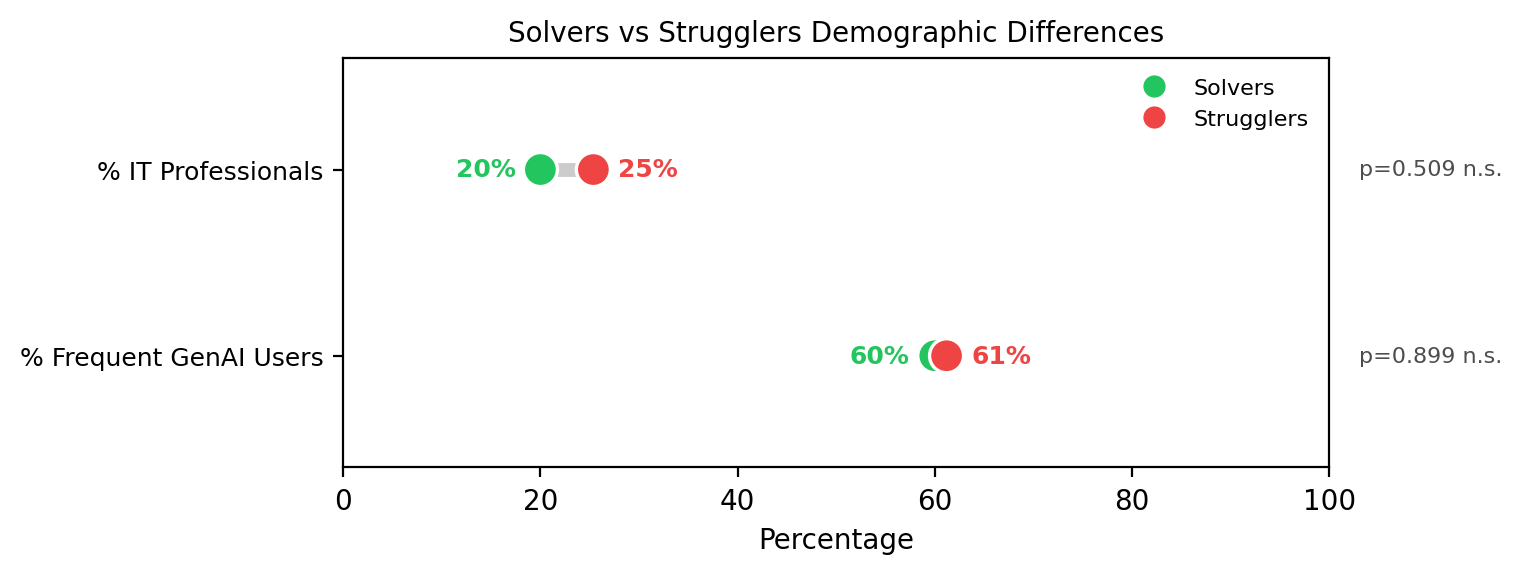

In [60]:
# --- Binary demographic splits: dumbbell (Solvers vs Strugglers gap) ---
# Same two comparisons as the chi-square / grouped-bar cells; one row per metric with a
# green Solvers-dot and red Strugglers-dot on a shared 0-100% axis, gap length = the effect.
# Group identity is in the legend; only the % value labels each dot (keeps text off the
# y-axis labels), and the chi-square p-value gets its own column in the right margin.
METRICS = [
    ("% IT Professionals", "occupation", lambda v: v == "it"),
    ("% Frequent GenAI Users", "genai_usage", lambda v: v in FREQUENT_GENAI),
]
WON_C, LOST_C = "#22c55e", "#ef4444"

def _posfrac(rows, field, pred):
    vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
    pos = sum(1 for v in vals if pred(v)); tot = len(vals) or 1
    return pos / tot, pos, len(vals)

def _pstar(field, pred):
    def cnt(rows):
        vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
        p = sum(1 for v in vals if pred(v)); return p, len(vals) - p
    wp, wn = cnt(_won); lp, ln = cnt(_lost)
    _, p, _, exp = _stats.chi2_contingency(np.array([[wp, wn], [lp, ln]]), correction=False)
    star = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "n.s."
    return p, star, exp.min()

import matplotlib.transforms as mtransforms
fig, axd = plt.subplots(figsize=(8.5, 3.2))
y = np.arange(len(METRICS))[::-1]                     # first metric on top
p_trans = mtransforms.blended_transform_factory(axd.transAxes, axd.transData)  # x=axes, y=data
for yi, (label, f, p) in zip(y, METRICS):
    wf, lf = 100 * _posfrac(_won, f, p)[0], 100 * _posfrac(_lost, f, p)[0]
    axd.plot([wf, lf], [yi, yi], color="0.8", lw=5, zorder=1, solid_capstyle="round")
    axd.scatter([wf, lf], [yi, yi], s=150, color=[WON_C, LOST_C], zorder=3,
                edgecolor="white", lw=1.2)
    # short % label on the OUTER side of each dot (smaller -> left, larger -> right)
    lo, hi = (wf, WON_C), (lf, LOST_C)
    if wf > lf: lo, hi = hi, lo
    axd.annotate(f"{lo[0]:.0f}%", (lo[0], yi), xytext=(-9, 0), textcoords="offset points",
                 ha="right", va="center", fontsize=9, color=lo[1], fontweight="bold")
    axd.annotate(f"{hi[0]:.0f}%", (hi[0], yi), xytext=(9, 0), textcoords="offset points",
                 ha="left", va="center", fontsize=9, color=hi[1], fontweight="bold")
    pv, star, _ = _pstar(f, p)
    axd.text(1.03, yi, f"p={pv:.3f} {star}", transform=p_trans, va="center",
             ha="left", fontsize=8, color="0.3", clip_on=False)
axd.set_yticks(y); axd.set_yticklabels([m[0] for m in METRICS], fontsize=9)
axd.set_xlim(0, 100); axd.set_ylim(-0.6, len(METRICS) - 0.4)
axd.set_xlabel("Percentage")
axd.set_title("Solvers vs Strugglers Demographic Differences", fontsize=10)
handles = [plt.Line2D([0], [0], marker="o", ls="", ms=9, mfc=c, mec="white", label=nm)
           for nm, c in [("Solvers", WON_C), ("Strugglers", LOST_C)]]
axd.legend(handles=handles, loc="upper right", ncol=1, frameon=False, fontsize=8)  # empty corner
fig.subplots_adjust(left=0.24, right=0.82, top=0.84, bottom=0.20)   # room for y-labels + p-column
plt.show()


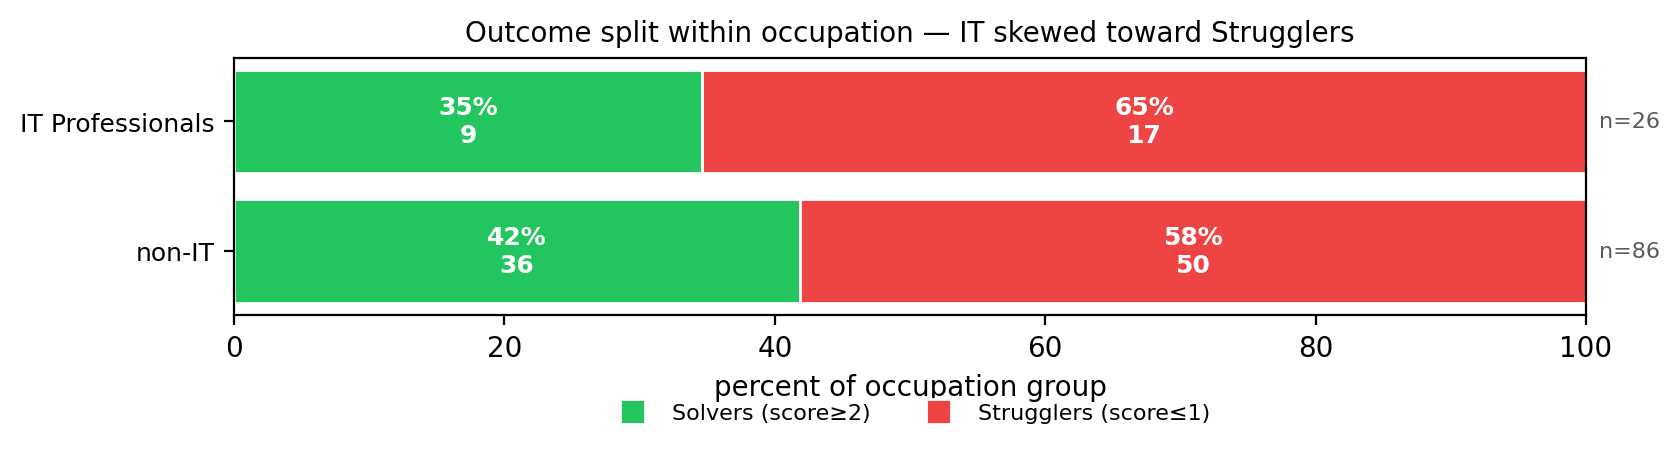

In [61]:
# --- Within-occupation outcome split: horizontal stacked bars ---
# Flips the conditioning of the charts above: instead of "% of Solvers who are IT",
# this asks "of IT professionals, what share were Solvers vs Strugglers?" Each row is a
# 100%-stacked bar (Solvers=green, Strugglers=red). non-IT row added for contrast.
def _demo(pids):
    return [json.load(open(RECORDINGS_BASE / pid / "demographics.json"))
            for pid in pids if (RECORDINGS_BASE / pid / "demographics.json").exists()]
_won, _lost = _demo(good_pid), _demo(bad_pid)
WON_C, LOST_C = "#22c55e", "#ef4444"

ROWS = [
    ("IT Professionals", lambda d: d.get("occupation") == "it"),
    ("non-IT",           lambda d: d.get("occupation") not in (None, "", "it")),
]

fig, axo = plt.subplots(figsize=(8.5, 2.8))
y = np.arange(len(ROWS))[::-1]                      # first row on top
for yi, (label, pred) in zip(y, ROWS):
    s = sum(1 for d in _won  if pred(d))            # Solvers in this occupation
    t = sum(1 for d in _lost if pred(d))            # Strugglers in this occupation
    tot = s + t or 1
    sp, tp = 100 * s / tot, 100 * t / tot
    axo.barh(yi, sp,        color=WON_C,  edgecolor="white")
    axo.barh(yi, tp, left=sp, color=LOST_C, edgecolor="white")
    if sp > 8:
        axo.text(sp / 2, yi, f"{sp:.0f}%\n{s}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    if tp > 8:
        axo.text(sp + tp / 2, yi, f"{tp:.0f}%\n{t}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    axo.text(101, yi, f"n={tot}", va="center", ha="left", fontsize=8, color="0.35")

axo.set_yticks(y); axo.set_yticklabels([r[0] for r in ROWS], fontsize=9)
axo.set_xlim(0, 100); axo.set_xlabel("percent of occupation group")
axo.set_title("Outcome split within occupation \u2014 IT skewed toward Strugglers", fontsize=10)
handles = [plt.Line2D([0], [0], marker="s", ls="", ms=9, mfc=c, mec="white", label=nm)
           for nm, c in [("Solvers (score\u22652)", WON_C), ("Strugglers (score\u22641)", LOST_C)]]
axo.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.5),
           ncol=2, frameon=False, fontsize=8)
plt.tight_layout(); plt.show()


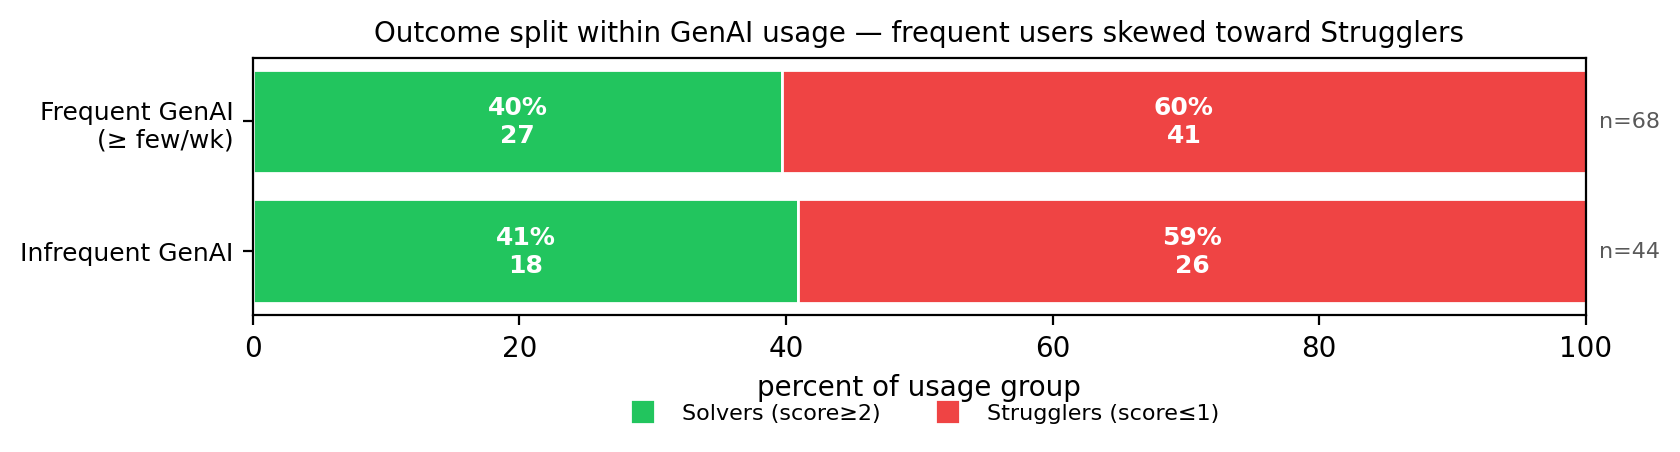

In [62]:
# --- Within-GenAI-usage outcome split: horizontal stacked bars ---
# Same flip as the occupation cell, but by AI fluency: "of frequent GenAI users, what
# share were Solvers vs Strugglers?" Frequent = few_times_week/daily/several_times_day
# (weekly counts as infrequent, matching FREQUENT_GENAI above). Rows 100%-stacked.
try:
    FREQUENT_GENAI
except NameError:
    FREQUENT_GENAI = {"few_times_week", "daily", "several_times_day"}
def _demo(pids):
    return [json.load(open(RECORDINGS_BASE / pid / "demographics.json"))
            for pid in pids if (RECORDINGS_BASE / pid / "demographics.json").exists()]
_won, _lost = _demo(good_pid), _demo(bad_pid)
WON_C, LOST_C = "#22c55e", "#ef4444"

def _gv(d):
    v = d.get("genai_usage"); return None if v in (None, "") else v
ROWS = [
    ("Frequent GenAI\n(\u2265 few/wk)", lambda d: _gv(d) in FREQUENT_GENAI),
    ("Infrequent GenAI",              lambda d: _gv(d) is not None and _gv(d) not in FREQUENT_GENAI),
]

fig, axg = plt.subplots(figsize=(8.5, 2.8))
y = np.arange(len(ROWS))[::-1]                      # first row on top
for yi, (label, pred) in zip(y, ROWS):
    s = sum(1 for d in _won  if pred(d))            # Solvers in this usage band
    t = sum(1 for d in _lost if pred(d))            # Strugglers in this usage band
    tot = s + t or 1
    sp, tp = 100 * s / tot, 100 * t / tot
    axg.barh(yi, sp,        color=WON_C,  edgecolor="white")
    axg.barh(yi, tp, left=sp, color=LOST_C, edgecolor="white")
    if sp > 8:
        axg.text(sp / 2, yi, f"{sp:.0f}%\n{s}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    if tp > 8:
        axg.text(sp + tp / 2, yi, f"{tp:.0f}%\n{t}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    axg.text(101, yi, f"n={tot}", va="center", ha="left", fontsize=8, color="0.35")

axg.set_yticks(y); axg.set_yticklabels([r[0] for r in ROWS], fontsize=9)
axg.set_xlim(0, 100); axg.set_xlabel("percent of usage group")
axg.set_title("Outcome split within GenAI usage \u2014 frequent users skewed toward Strugglers", fontsize=10)
handles = [plt.Line2D([0], [0], marker="s", ls="", ms=9, mfc=c, mec="white", label=nm)
           for nm, c in [("Solvers (score\u22652)", WON_C), ("Strugglers (score\u22641)", LOST_C)]]
axg.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.5),
           ncol=2, frameon=False, fontsize=8)
plt.tight_layout(); plt.show()
